# Loading Packages

In [1]:
# Linear Algebra
using LinearAlgebra
# File Handling
using Glob, FITSIO, Serialization, HDF5, DelimitedFiles, LibGit2, Suppressor, JLD2, CSV
# Stats
using StatsBase, Distributions, FreqTables, LsqFit, DataStructures, Optim
using BinnedStatistics, KrylovKit, ImageTransformations
import FastRunningMedian: running_median
# Computing
using DataFrames, ProgressMeter, Distributed, PrettyChairmarks, ImageFiltering
using Random, Interpolations, SparseArrays, EllipsisNotation, ShiftedArrays, ParallelDataTransfer
# Astro
using Healpix, SkyCoords, WCS, AstroTime, DustExtinction
# String Formatting
using LaTeXStrings
# Plotting
using CairoMakie
black_latexfonts = merge(theme_black(), theme_latexfonts()); white_latexfonts = theme_latexfonts()
set_theme!(black_latexfonts); CairoMakie.disable_mime!("svg", "pdf", "text/html");
using ColorSchemes

HTML("<style>.jp-Notebook { max-width: 100% !important; }</style>")


libgomp: Invalid value for environment variable OMP_NUM_THREADS: invalid
[ Info: Precompiling DustExtinction [fb44c06c-c62f-5397-83f5-69249e0a3c8e] (cache misses: target mismatch (2))
┌ Warning: attempting to remove probably stale pidfile
│   path = "/home/cj1223/.julia/compiled/v1.11/BSplineKit/VlADV_aCqjF.ji.pidfile"
└ @ FileWatching.Pidfile /scratch/gpfs/LICENSED/x86_64/julia/1.11.1/share/julia/stdlib/v1.11/FileWatching/src/pidfile.jl:249

libgomp: Invalid value for environment variable OMP_NUM_THREADS: invalid

libgomp: Invalid value for environment variable OMP_NUM_THREADS: invalid

libgomp: Invalid value for environment variable OMP_NUM_THREADS: invalid
[ Info: Precompiling InterpolationsUnitfulExt [39de6958-b8ab-5ce0-9a8f-2bc2e9e79136] (cache misses: target mismatch (2))
[ Info: Precompiling UnitfulExt [cec040eb-2c6f-535f-9e61-ace7f7dfceae] (cache misses: target mismatch (2))
[ Info: Precompiling ConstructionBaseUnitfulExt [2b7dcb06-1a74-5ae7-a318-b62feea60883] (cache misses: t

HTML{String}("<style>.jp-Notebook { max-width: 100% !important; }</style>")

# To Do

Taking this julia notebook …, I want to add a cell plotting the following:  A four panel figure, with top left, A v B (see how this is implemented already), with the database points coloured by amu
bottom left A vs (A-B)/A, , with the database points coloured by amu
top right (A-B)/A vs (B-C)/B, this subpanel should be labelled pure geometry space, with the x-axis labelled prolate axis and the y-axis labelled oblate axis, and it should have a dotted line going through the plane parametrized by y = (1 - x)/(2 - x), labelled “Pure planar geometry”. The database points should be coloured by kappa, rays assymmetry parameter.
bottom right then (B-C)/B v B

All axes should have our corresponding posterior contours on them.

Also, make a cell with the following

A two panel figure, with
- left, A v B (see how this is implemented already), with the database points coloured by atomic weight in amu. The colourbar should be the yellow-purple one already in place, and labelled as it is now. The label of this subplot should be “Molecular 2D Sizes”
- right (A-B)/A vs (B-C)/B, this subpanel should be labelled ”Pure Geometry”, with the x-axis labelled prolate axis [(A-B)/A] and the y-axis labelled oblate axis [(B-C)/B], and it should have a dotted line going through the plane parametrized by y = (1 - x)/(2 - x), labelled “Planar Geometry”. The database points should be coloured by kappa (blue white red colourmap from -1 to 1), and the colourbar should be labelled Ray’s assymetry parameter (\kappa). Ideally if possible, annotate the colorbar with rotated text near +1 as More oblate, and near -1 as more prolate.

All axes should have our corresponding posterior contours on them.

Also, make a cell with the following

A two panel figure, with
- left, A v B (see how this is implemented already), with the database points coloured by atomic weight in amu. The colourbar should be the yellow-purple one already in place, and labelled as it is now. The label of this subplot should be “Molecular 2D Sizes”. It would be great to make a secondary axis showing the length along that axis from calculating I_X, assuming that every atom is carbon so that  
- right (A-B)/A vs (B-C)/B, this subpanel should be labelled ”Pure Geometry”, with the x-axis labelled prolate axis [(A-B)/A] and the y-axis labelled oblate axis [(B-C)/B], and it should have a dotted line going through the plane parametrized by y = (1 - x)/(2 - x), labelled “Planar Geometry”. The database points should be coloured by delta/IC (blue white red colourmap from -5 to 5), and the colourbar should be labelled Normalized Inertial Defect (\delta/I_c)

All axes should have our corresponding posterior contours on them.


# Download + Parse PAHdB structural database

In [2]:
include("parse_pahdb.jl")

In [3]:
# Parse the database
filename = "pahdb-complete-theoretical-v4.00-alpha_kacca9ms0lgo93HfUcn.ascii"
entries = parse_pahdb(filename);

# Convert to rotational constants

In [4]:
function get_rot_const(x,y,z,massvec)
    com_x, com_y, com_z = mean(x,weights(massvec)), mean(y,weights(massvec)), mean(z,weights(massvec))
    x .-= com_x
    y .-= com_y
    z .-= com_z;
    Ixx = sum(massvec.*(y.^2 .+ z.^2)) # amu A^2
    Ixy = -sum(massvec.*x.*y) # amu A^2
    Ixz = -sum(massvec.*x.*z) # amu A^2

    Iyx = Ixy
    Iyy = sum(massvec.*(x.^2 .+ z.^2)) # amu A^2
    Iyz = -sum(massvec.*y.*z) # amu A^2

    Izx = Ixz
    Izy = Iyz
    Izz = sum(massvec.*(x.^2 .+ y.^2)) # amu A^2

    Imat = [
        Ixx Ixy Ixz;
        Iyx Iyy Iyz;
        Izx Izy Izz]

    elist = eigvals(Symmetric(Imat))
    Bvec = IamuA2_Bcminv.(elist)
    return sort(Bvec,rev=true)
end

IamuA2_Bcminv(I) = 16.857629206/I

function rasym_param(A,B,C)
    return (2*B-A-C)/(A-C)
end

function convert2I(B)
    return 16.857629206/B
end

function L_from_B(B; a_cc=1.42)
    """Long axis in Å from B in cm⁻¹, assuming acene-like single-ring width."""
    return (12 * 16.8576 * a_cc / (32 * B))^(1/3)
end

L_from_B (generic function with 1 method)

In [5]:
function rasym_param(A,B,C)
    return (2*B-A-C)/(A-C)
end

rasym_param (generic function with 1 method)

In [6]:
rasym_param(1.001,0.0505,0.05)

-0.9989484752891694

In [7]:
function rot_const_wrapper(entry)
    xyzm = get_xyzm_vectors(entry, rounding=true)
    M = sum(xyzm.mass)
    return get_rot_const(xyzm.x,xyzm.y,xyzm.z,xyzm.mass), M
end

rot_const_wrapper (generic function with 1 method)

In [8]:
pout = @showprogress pmap(rot_const_wrapper, entries);

Progress: 100%|█████████████████████████████████████████| Time: 0:00:05


In [9]:
ABCmat = zeros(3,length(pout))
Mmat = zeros(length(pout))
@showprogress for (indx, subp) in enumerate(pout)
    ABCmat[:,indx] .= subp[1]
    Mmat[indx] = subp[2]
end

Progress: 100%|█████████████████████████████████████████| Time: 0:00:00


# Posterior loading

In [180]:
# f = h5open("../2025_10_04/bc_run_SymmetryC2v_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p05_update.h5")


# base_path = expanduser("~/../../scratch/gpfs/MELCHIOR/cj1223/DIB/")
# for file in readdir(base_path)
#     fullpath = base_path*file
#     !isfile(fullpath) && continue
#     f = h5open(fullpath)
#     chain = read(f["mcmc/chain"])
#     if length(chain[1,:,:][:])>15000
#         println(file)
#     close(f)
#     end
# end

base_path = expanduser("~/../../scratch/gpfs/MELCHIOR/cj1223/DIB/")
for file in readdir(base_path)
    full_path = joinpath(base_path, file)
    !isfile(full_path) && continue
    f = try
        h5open(full_path)
    catch e
        @warn "Skipping $file: $e"
        continue
    end
    chain = read(f["mcmc/chain"])
    if length(chain[1,:,:][:]) > 15000 && occursin("15672", file) && occursin("Cs", file)
        println(file)
    end
    close(f)
end

# file = "15672_run_DIB15672_SymmetryC2v_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p15_errPlate_trunc10_balanceErrTrue_dTcenterNone_centeroffset0p15_test.h5"

file = "15672_run_DIB15672_SymmetryCs_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p15_errPlate_trunc10_balanceErrTrue_dTcenterNone_centeroffset0p15_test.h5"
# file = "15672_run_DIB15672_SymmetryCs_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p15_errDefault_trunc10_balanceErrTrue_dTcenterNone_centeroffset0p15_test.h5"
f = h5open(base_path*file)
chain = read(f["mcmc/chain"])
close(f)

println("Chosen file:")
println(file)

15672_run_DIB15672_SymmetryCs_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p15_errDefault_trunc10_balanceErrTrue_dTcenterNone_centeroffset0p15_test.h5
15672_run_DIB15672_SymmetryCs_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p15_errPlate_trunc10_balanceErrTrue_dTcenterNone_centeroffset0p15_test.h5
15672_run_SymmetryCs_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTFalse_covFalse_nonlinFalse_tauSlope0p05_alphaSlope0p01_errPlate_trunc10_balanceErrFalse_dTcenterTrue_test.h5


┌ Warning: Skipping pgo_temppy_DIB15272_SymmetryCs_BCFalse_F1p0_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p05_alphaSlope0p14_errpca_default_trunc0_balanceErrTrue_dTcenter[10.0,: ErrorException("unable to determine if /home/cj1223/../../scratch/gpfs/MELCHIOR/cj1223/DIB/pgo_temppy_DIB15272_SymmetryCs_BCFalse_F1p0_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p05_alphaSlope0p14_errpca_default_trunc0_balanceErrTrue_dTcenter[10.0, is accessible in the HDF5 format (file may not exist)")
└ @ Main In[180]:23
┌ Warning: Skipping test0.txt: ErrorException("unable to determine if /home/cj1223/../../scratch/gpfs/MELCHIOR/cj1223/DIB/test0.txt is accessible in the HDF5 format (file may not exist)")
└ @ Main In[180]:23


Chosen file:
15672_run_DIB15672_SymmetryCs_BCTrue_F1p0_DTrue_FlatFalse_SpecTrue_dTTrue_covFalse_nonlinFalse_tauSlope0p15_alphaSlope0p15_errPlate_trunc10_balanceErrTrue_dTcenterNone_centeroffset0p15_test.h5


In [181]:
burnin = 4000;

T = chain[1,:,burnin:end][:]
C = chain[4,:,burnin:end][:]
B = chain[3,:,burnin:end][:]
A = chain[2,:,burnin:end][:];
aC = chain[5,:,burnin:end][:]
aB = chain[6,:,burnin:end][:]
aA = chain[7,:,burnin:end][:];

# mask = B .< 0.0125
mask = (B .< 100) .& (B .> 0.0001)

T  = T[mask]
A  = A[mask]
B  = B[mask]
C  = C[mask]
aC = aC[mask]
aB = aB[mask]
aA = aA[mask]

mask = C .> B
B[mask], C[mask] = C[mask], B[mask]
aB[mask], aC[mask] = aC[mask], aB[mask]
print(sum(mask))

median(A), median(B), median(C)

0

(0.08568964467439208, 0.0437195103152736, 0.0049289264591069895)

In [182]:
#It ranges from -1 to +1 and describes where a molecule sits on the asymmetric top spectrum:
# κ = -1 → prolate symmetric top (A >> B = C, cigar-shaped)
# κ = +1 → oblate symmetric top (A = B >> C, disc-shaped)
# κ = 0 → most asymmetric case

kap_vec_post = rasym_param.(A,B,C)
Ia_post = convert2I.(A)
Ib_post = convert2I.(B)
Ic_post = convert2I.(C)
Iprod_post = Ia_post.*Ib_post.*Ic_post;
# Δ_post = Ic_post.-Ib_post.-Ia_post;
# Δ_post = @. Ic_post - Ib_post - Ia_post; #inertial defect, measures how planar a molecule is — for a perfectly planar molecule Δ = 0

Δ_post = @. Ic_post - Ib_post; #inertial defect, measures how planar a molecule is — for a perfectly planar molecule Δ = 0
Δ_post -= Ia_post;

In [183]:
Ic_post

238272-element Vector{Float64}:
 2509.0445994985444
 2502.885127509597
 3955.7109665620346
 5798.34370071235
 4501.3220780391175
 3700.9937789547052
 2551.7961768572704
 5115.204147662729
 1810.2657035025504
 3450.711026305588
 2819.7698504767563
 3543.9213969925086
 6346.255499587279
    ⋮
 2877.77951021353
 3532.9508878944575
 3440.5015972779415
 2464.7858150825273
 2380.157207778537
 4001.9390846406027
 2095.8821866485705
 1715.947497068201
 3495.759326938016
 5430.04188602842
 3460.684257389023
 2215.46469826286

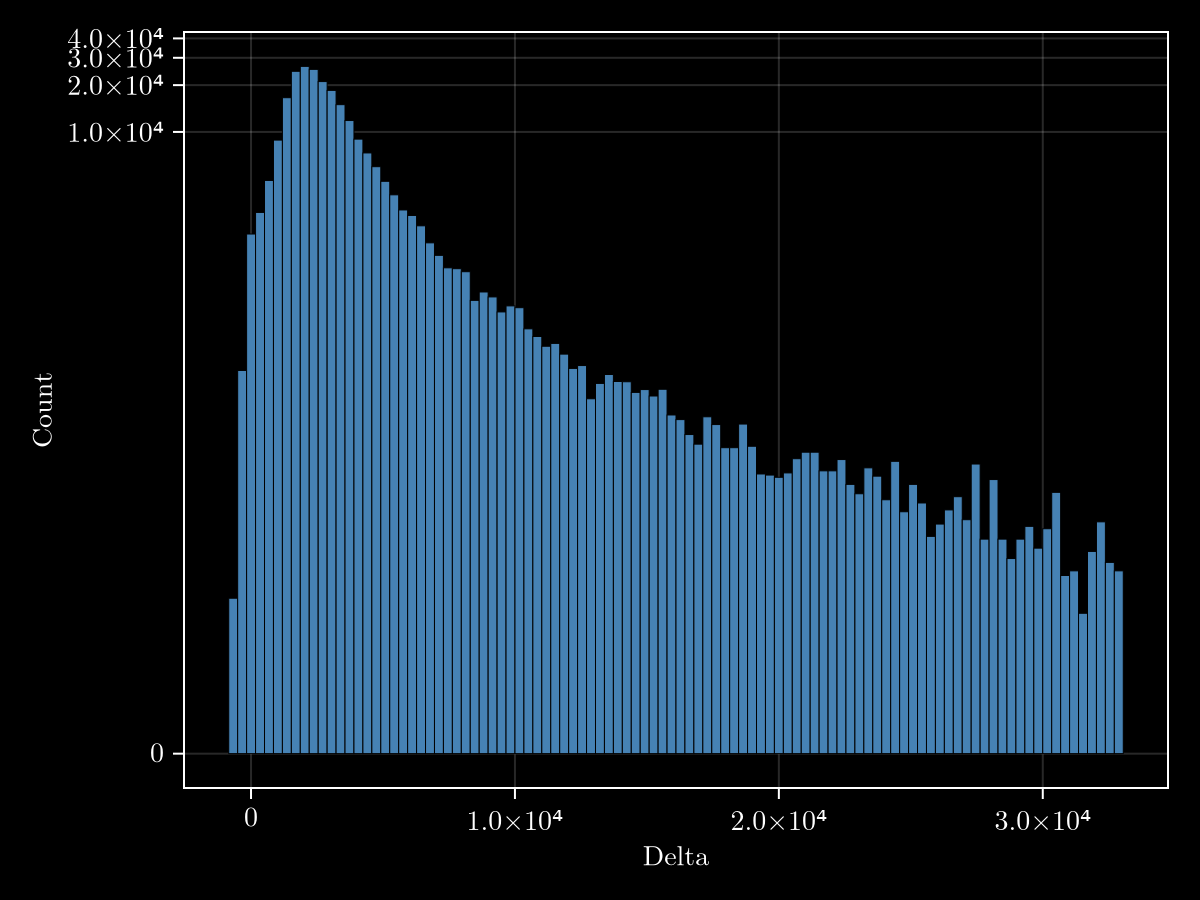

In [184]:
# fig, ax, h = hist(log10.(Δ_post), bins=100, color=:steelblue, strokewidth=0.5, strokecolor=:black)
fig, ax, h = hist(Δ_post , bins=100, color=:steelblue, strokewidth=0.5, strokecolor=:black)
ax.yscale = Makie.pseudolog10
ax.xlabel = "Delta"
ax.ylabel = "Count"
fig

In [139]:
function get_delta(A,B,C)
    return convert2I(C)-convert2I(A)-convert2I(B)
end

get_iprod(A,B,C) = convert2I(A)*convert2I(B)*convert2I(C)

get_iprod (generic function with 1 method)

In [140]:
df = DataFrame(;T, A, B);

In [141]:
using PairPlots

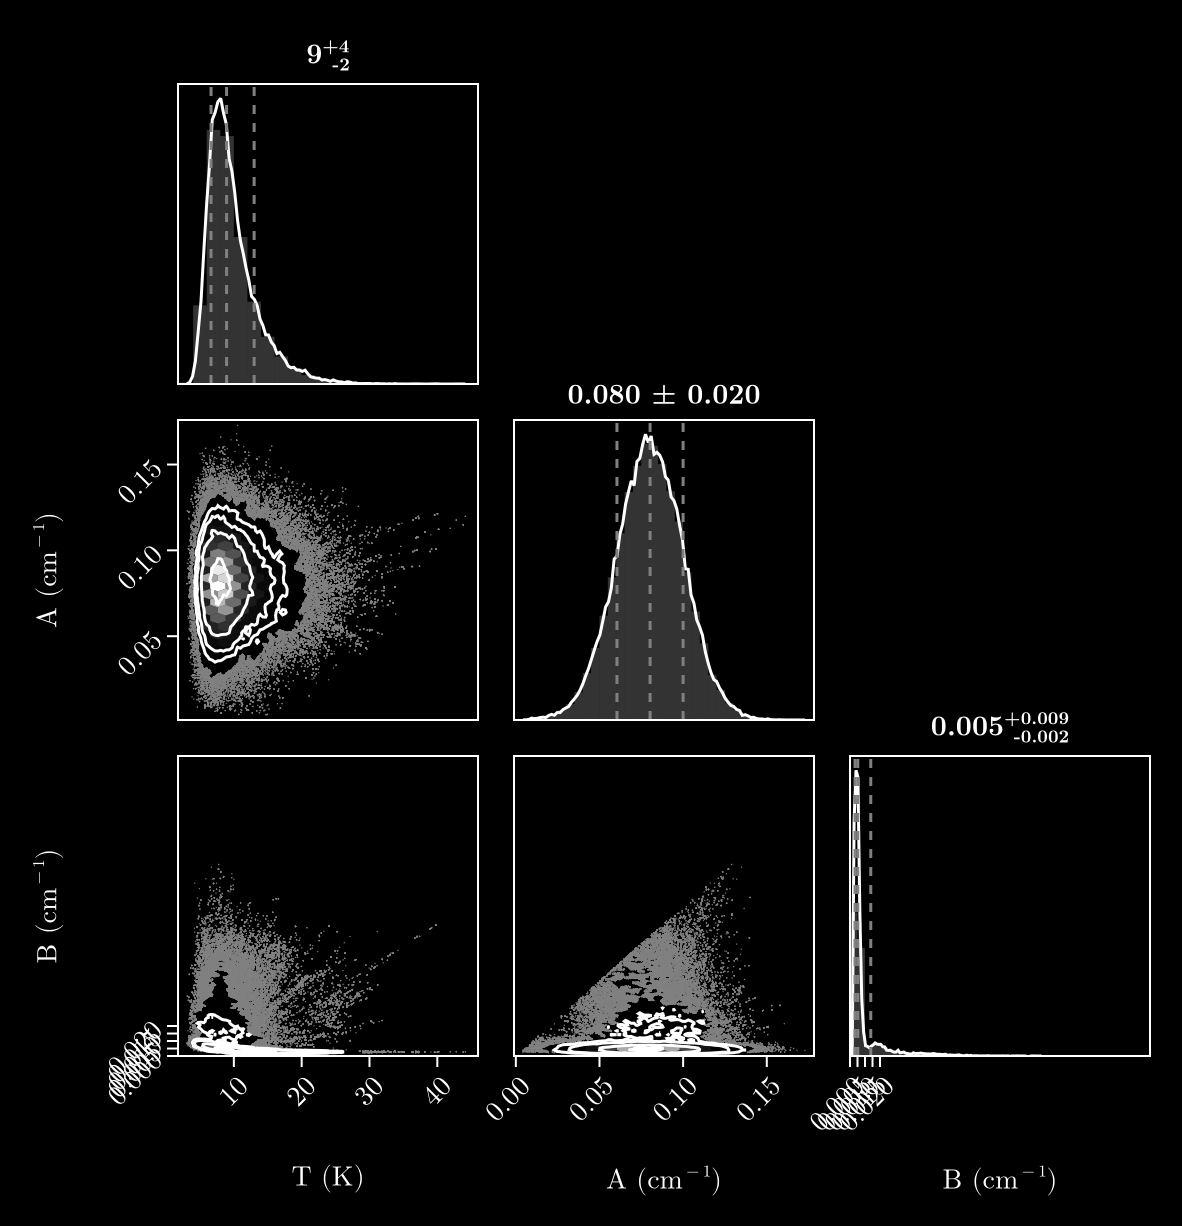

In [142]:
pairplot(df => (
        PairPlots.HexBin(colormap=Makie.cgrad([:transparent, :white])),
        PairPlots.Scatter(filtersigma=3, color=:grey),
        PairPlots.Contour(color=:white),
        PairPlots.MarginHist(color=(:white, 0.2)),
        PairPlots.MarginDensity(bandwidth=0.3, color="white"),
        PairPlots.MarginQuantileText(color="white"),
        PairPlots.MarginQuantileLines(color="grey"),
    ), 
    axis=(;
        B=(;
        ticks=([0.0,0.005,0.010,0.015,0.020]),
        lims=(;low=0,high=0.2),
        ),
    ),
    labels = Dict(
    :T => L"\text{T (K)}",
    :A => L"A (cm$^{-1}$)",
    :B => L"B (cm$^{-1}$)",
))

In [143]:
median(A), median(B), median(C)

(0.08024067059939953, 0.005184713463249835, 0.00401232156717877)

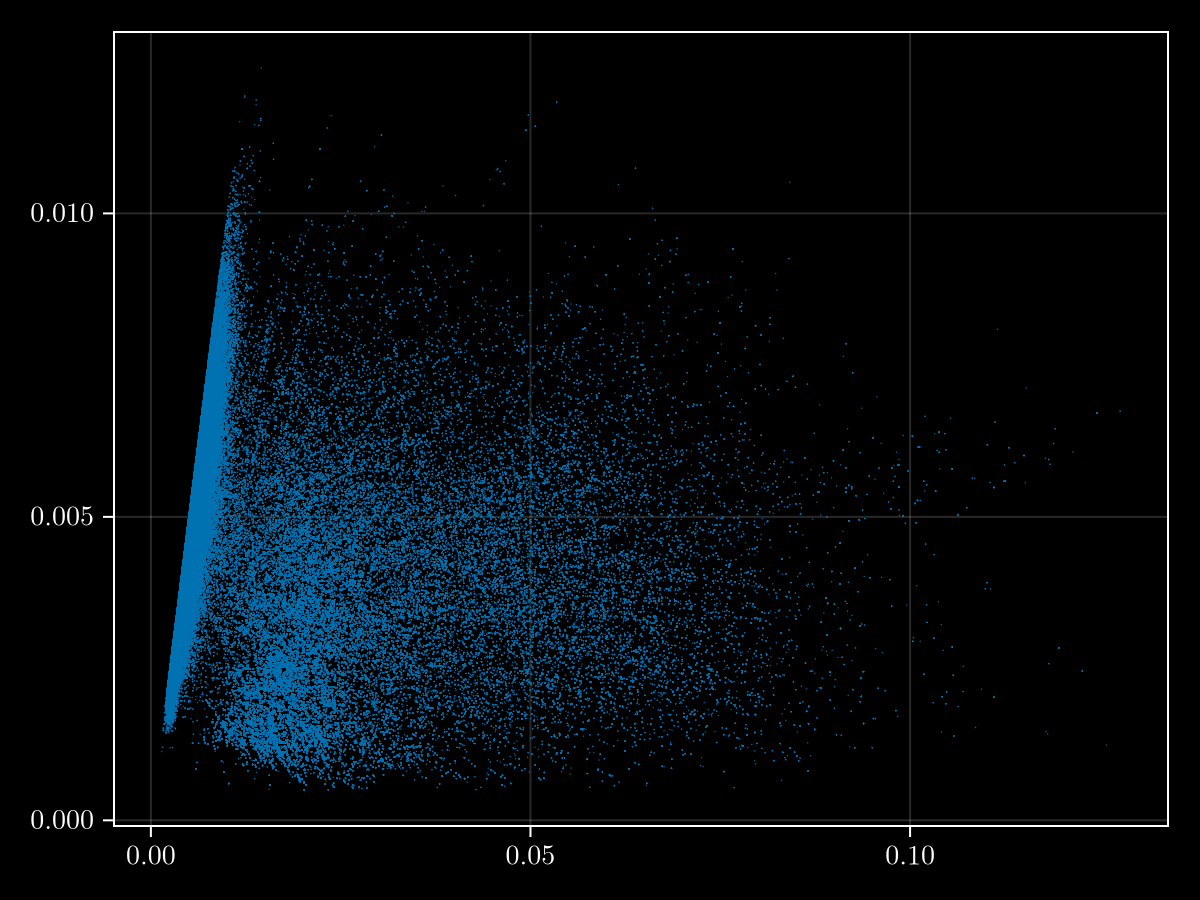

In [144]:
scatter(B, C, markersize=1)

lets start simpler, and just make a hexbin histogram behind the plot

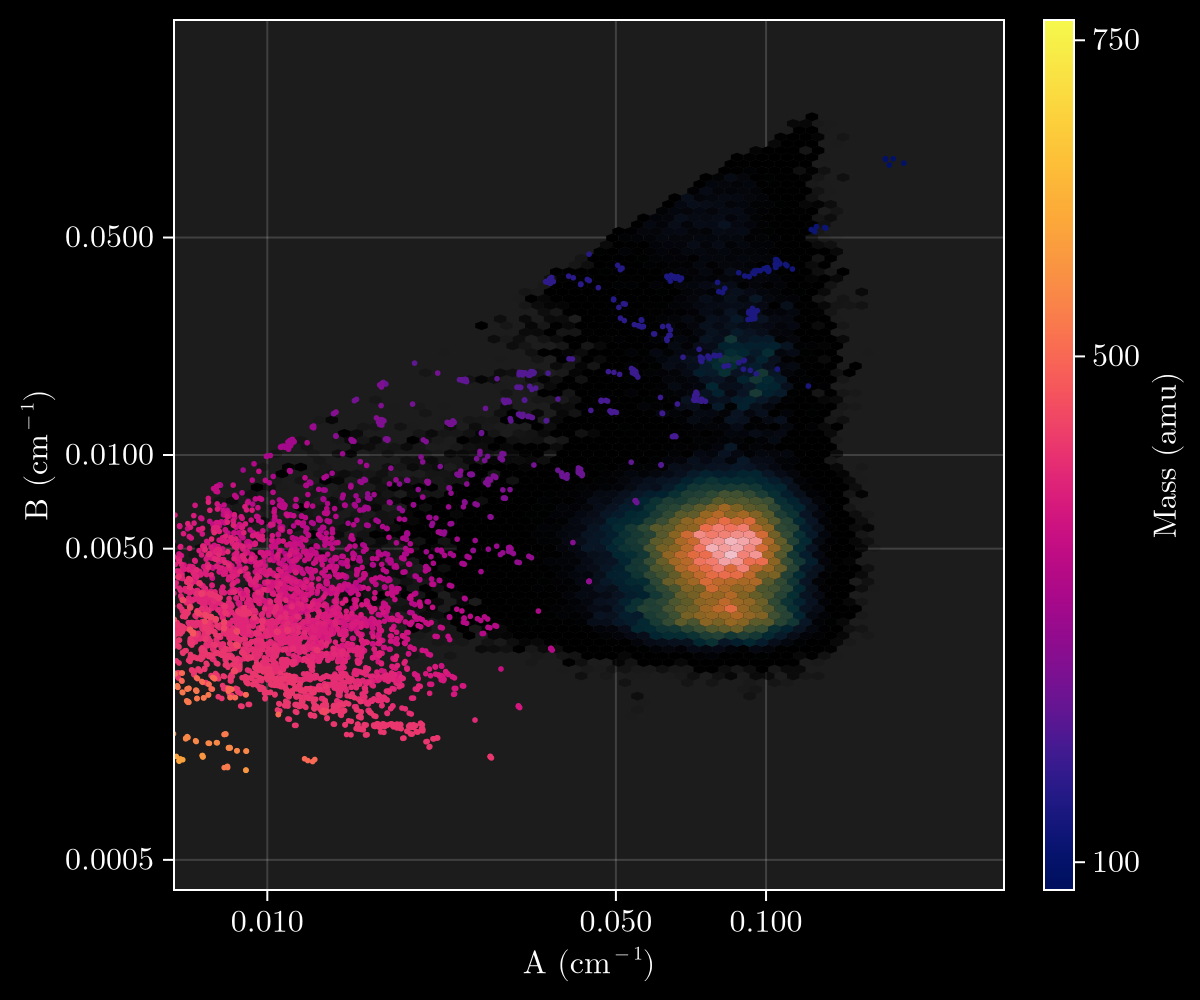

In [145]:
fig = Figure(size=(600, 500), fontsize=16,
    figure_padding=(10,10,10,10))
    
ax = Axis(fig[1, 1],
    xscale=log10,
    yscale=log10,
    xticks = [5e-3,1e-2,5e-2,1e-1],
    yticks = [5e-4,1e-4,5e-3,1e-2,5e-2],
    xlabel=L"A (cm$^{-1}$)",
    ylabel=L"B (cm$^{-1}$)",
    backgroundcolor = :grey11,
)

# xlims!(ax,6.5e-3,1e-1)
# ylims!(ax,4e-4,2.5e-2)

xlims!(ax,6.5e-3,3e-1)
ylims!(ax,4e-4,2.5e-1)

co = hexbin!(ax,A,B,
    cellsize = 0.025,
    threshold = 0.0,
    colormap = [Makie.to_color(:transparent); Makie.to_colormap(ColorSchemes.cmr_dusk)],
    # colorrange = (0,100),
)

co = scatter!(ax,ABCmat[1,:],ABCmat[2,:],color=Mmat[:],
    colorrange=(78,766),
    colormap=ColorSchemes.linear_bmy_10_95_c71_n256, markersize=4)

Colorbar(fig[1, 2], co, width = 15, height = Relative(1), label="Mass (amu)", ticks=[100,500,750])

colgap!(fig.layout, 1, 20)

resize_to_layout!(fig)
fig

In [ ]:
fig = Figure(size=(600, 500), fontsize=16,
    figure_padding=(10,10,10,10))

ax = Axis(fig[1, 1],
    # xscale=log10,
    # yscale=log10,
    # yscale = Makie.pseudolog10,
    xticks = [5e-3,1e-2,5e-2,1e-1],
    # yticks = [5e-4,1e-4,5e-3,1e-2,5e-2],
    xlabel=L"I_a ",
    ylabel=L"I_c-I_b",
    backgroundcolor = :grey11,
)

# xlims!(ax,6.5e-3,1e-1)
# ylims!(ax,10^(0),10^(3.5))

co = hexbin!(ax,Ia_post, Δ_post,
    cellsize = (0.02,0.02),
    threshold = 0.0,
    colormap = [Makie.to_color(:transparent); Makie.to_colormap(ColorSchemes.cmr_dusk)],
    # colorrange = (0,100),
)

resize_to_layout!(fig)
fig

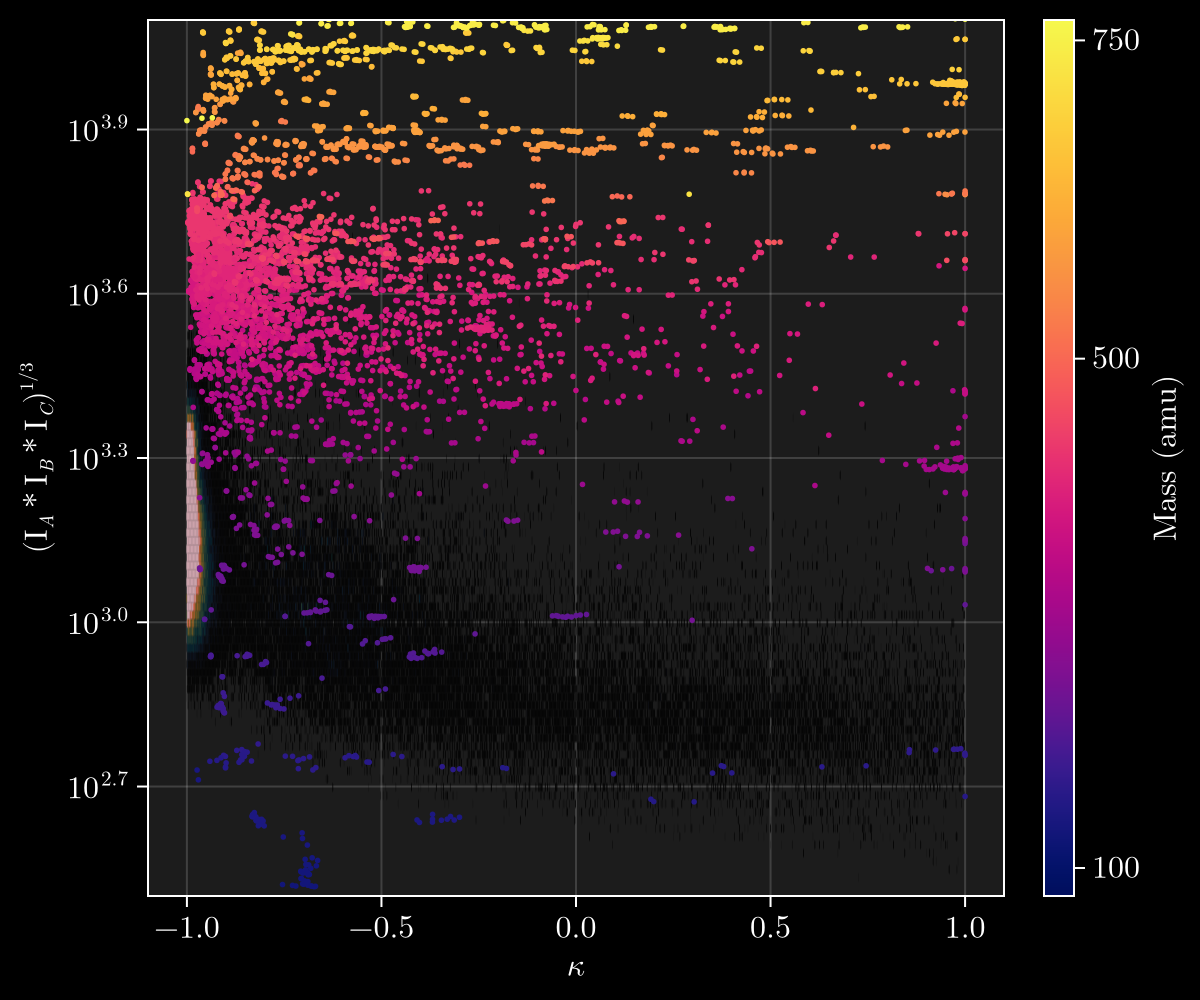

In [178]:
fig = Figure(size=(600, 500), fontsize=16,
    figure_padding=(10,10,10,10))
ax = Axis(fig[1, 1],
    # xscale=Makie.pseudolog10,
    yscale=log10,
    # xticks = [5e-4,5e-3],
    # yticks = [5e-4,1e-4,5e-3,1e-2,5e-2],
    xlabel=L"$\kappa$",
    ylabel=L"(I$_A$*I$_B$*I$_C$)$^{1/3}$",
    backgroundcolor = :grey11,
)

xlims!(ax,-1.1,1.1)
ylims!(ax,10^(2.5),10^(4.1))

co = hexbin!(ax,kap_vec_post,Iprod_post.^(1/3),
    cellsize = (0.002,0.02),
    threshold = 0.0,
    colormap = [Makie.to_color(:transparent); Makie.to_colormap(ColorSchemes.cmr_dusk)],
    colorrange = (0,1000),
)

co = scatter!(ax,kap_vec,Iprod.^(1/3),color=Mmat[:],
    colorrange=(78,766),
    colormap=ColorSchemes.linear_bmy_10_95_c71_n256, markersize=4)

Colorbar(fig[1, 2], co, width = 15, height = Relative(1), label="Mass (amu)", ticks=[100,500,750])

colgap!(fig.layout, 1, 20)

resize_to_layout!(fig)
fig

In [148]:
# fig = Figure(size=(600, 500), fontsize=16,
#     figure_padding=(10,10,10,10))
    
# ax = Axis(fig[2, 1],
#     xscale=log10,
#     yscale=log10,
#     xticks = [5e-3,1e-2,5e-2,1e-1],
#     yticks = [5e-4,1e-4,2e-3,1e-2,5e-2],
#     xlabel=L"A (cm$^{-1}$)",
#     ylabel=L"B (cm$^{-1}$)",
#     backgroundcolor = :grey11,
# )

# xlims!(ax,6.5e-3,1e-1)
# ylims!(ax,4e-4,2.5e-2)

# co = hexbin!(ax,A,B,
#     cellsize = 0.025,
#     threshold = 0.0,
#     colormap = [Makie.to_color(:transparent); Makie.to_colormap(ColorSchemes.cmr_dusk)],
#     # colorrange = (0,100),
# )

# co = scatter!(ax,ABCmat[1,:],ABCmat[2,:],color=Mmat[:],
#     colorrange=(78,766),
#     colormap=ColorSchemes.linear_bmy_10_95_c71_n256, markersize=4)

# ax = Axis(fig[1, 1],
#     xscale=log10,
#     yscale=log10,
#     xticks = [5e-3,1e-2,5e-2,1e-1],
#     yticks = [5e-4,1e-4,2e-3,1e-2,5e-2],
#     xlabel=L"A (cm$^{-1}$)",
#     ylabel=L"C (cm$^{-1}$)",
#     backgroundcolor = :grey11,
# )

# xlims!(ax,6.5e-3,1e-1)
# ylims!(ax,4e-4,2.5e-2)

# co = hexbin!(ax,A,C,
#     cellsize = 0.025,
#     threshold = 0.0,
#     colormap = [Makie.to_color(:transparent); Makie.to_colormap(ColorSchemes.cmr_dusk)],
#     # colorrange = (0,100),
# )

# co = scatter!(ax,ABCmat[1,:],ABCmat[3,:],color=Mmat[:],
#     colorrange=(78,766),
#     colormap=ColorSchemes.linear_bmy_10_95_c71_n256, markersize=4)

# ax = Axis(fig[2, 2],
#     xscale=log10,
#     yscale=log10,
#     xticks = [5e-4,1e-4,2e-3,1e-2,5e-2],
#     yticks = [5e-4,1e-4,2e-3,1e-2,5e-2],
#     xlabel=L"C (cm$^{-1}$)",
#     ylabel=L"B (cm$^{-1}$)",
#     backgroundcolor = :grey11,
# )

# xlims!(ax,4e-4,2.5e-2)
# ylims!(ax,4e-4,2.5e-2)

# co = hexbin!(ax,C,B,
#     cellsize = 0.025,
#     threshold = 0.0,
#     colormap = [Makie.to_color(:transparent); Makie.to_colormap(ColorSchemes.cmr_dusk)],
#     # colorrange = (0,100),
# )

# co = scatter!(ax,ABCmat[3,:],ABCmat[2,:],color=Mmat[:],
#     colorrange=(78,766),
#     colormap=ColorSchemes.linear_bmy_10_95_c71_n256, markersize=4)


# # Colorbar(fig[1, 2], co, width = 15, height = Relative(1), label="Mass (amu)", ticks=[100,500,750])

# # colgap!(fig.layout, 1, 20)

# resize_to_layout!(fig)
# fig

can we trust the BC posterior? Seems so degenerate and also somewhat inconsistent with DFT?

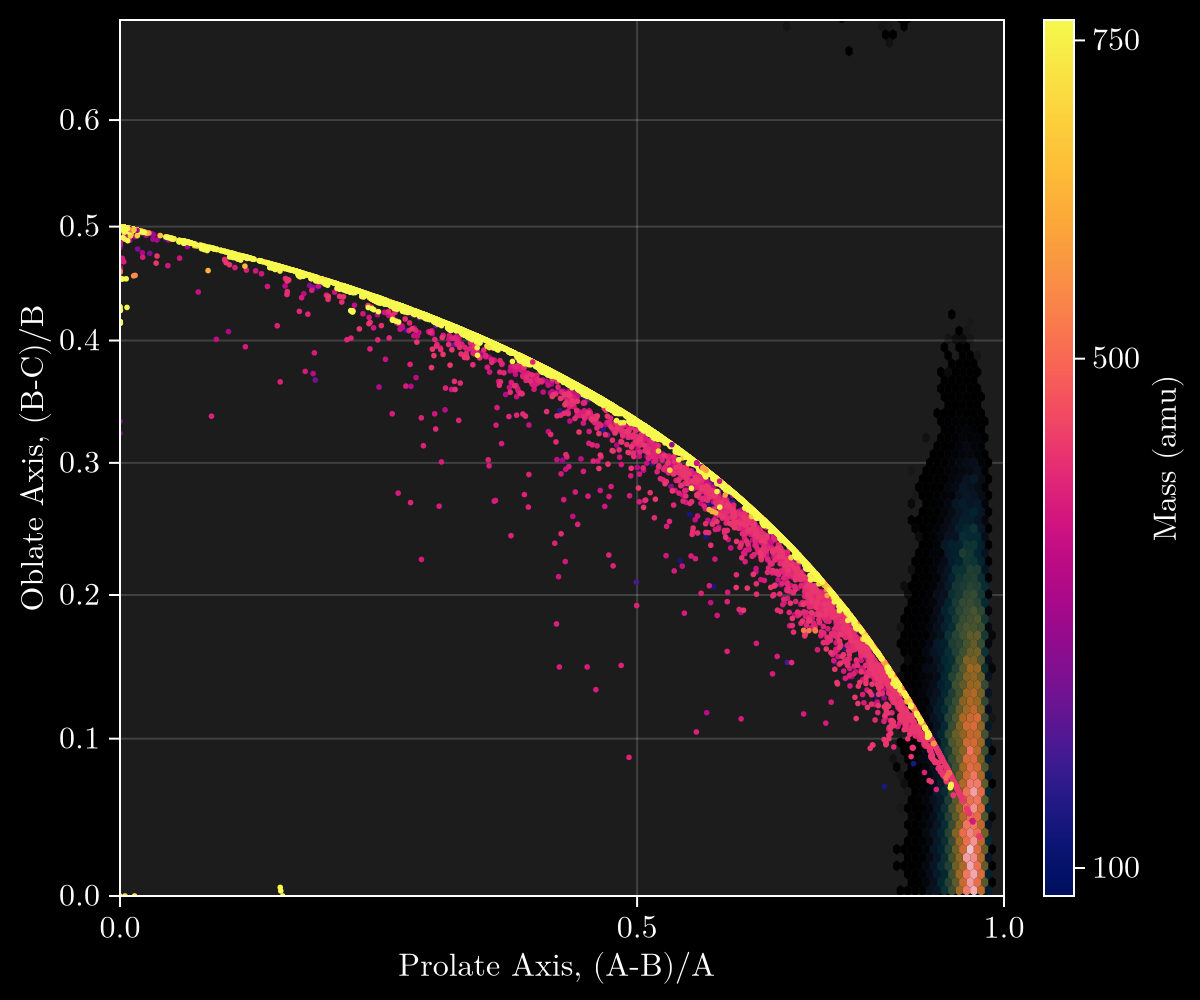

In [179]:
fig = Figure(size=(600, 500), fontsize=16,
    figure_padding=(10,10,10,10))
    
ax = Axis(fig[1, 1],
    xscale=Makie.pseudolog10,
    yscale=Makie.pseudolog10,
    # xticks = [5e-4,1e-4,2e-3,1e-2,5e-2],
    # yticks = [1e-5,5e-4,1e-4,2e-3,1e-2,5e-2],
    xlabel="Prolate Axis, (A-B)/A ",
    ylabel="Oblate Axis, (B-C)/B",
    backgroundcolor = :grey11,
)

xlims!(ax,0,1.0)
ylims!(ax,0,0.7)

co = hexbin!(ax,(A.-B)./A,(B.-C)./B,
    cellsize = 0.0025,
    threshold = 100,
    colormap = [Makie.to_color(:transparent); Makie.to_colormap(ColorSchemes.cmr_dusk)],
    # colorrange = (0,100),
)

co = scatter!(ax,(ABCmat[1,:].-ABCmat[2,:])./ABCmat[1,:],(ABCmat[2,:].-ABCmat[3,:])./ABCmat[2,:],color=Mmat[:],
    colorrange=(78,766),
    colormap=ColorSchemes.linear_bmy_10_95_c71_n256, markersize=4)

Colorbar(fig[1, 2], co, width = 15, height = Relative(1), label="Mass (amu)", ticks=[100,500,750])

colgap!(fig.layout, 1, 20)

resize_to_layout!(fig)
fig

# Radio Comparisons

In [151]:
cm2MHz = 505_379.0091/16.857_629_192;

In [152]:
tindx = findall(map(x->x.uid, entries) .== 495) # indene
ABCmat[:,tindx].*cm2MHz, Δ[tindx]

([3693.846786944025; 1589.044532562675; 1118.6533573320582;;], [-3.08154852835591])

In [153]:
tindx = findall(map(x->x.uid, entries) .== 55) # Phenalene
ABCmat[:,tindx].*cm2MHz, Δ[tindx]

([1083.8700294442126; 1080.897396125714; 542.9246081569623;;], [-2.982079996900154])

In [154]:
radio_list = [463, 465, 495, 55, 720]
msk = map(x->x.uid in radio_list, entries)
count(msk)

5

# Working in MHz

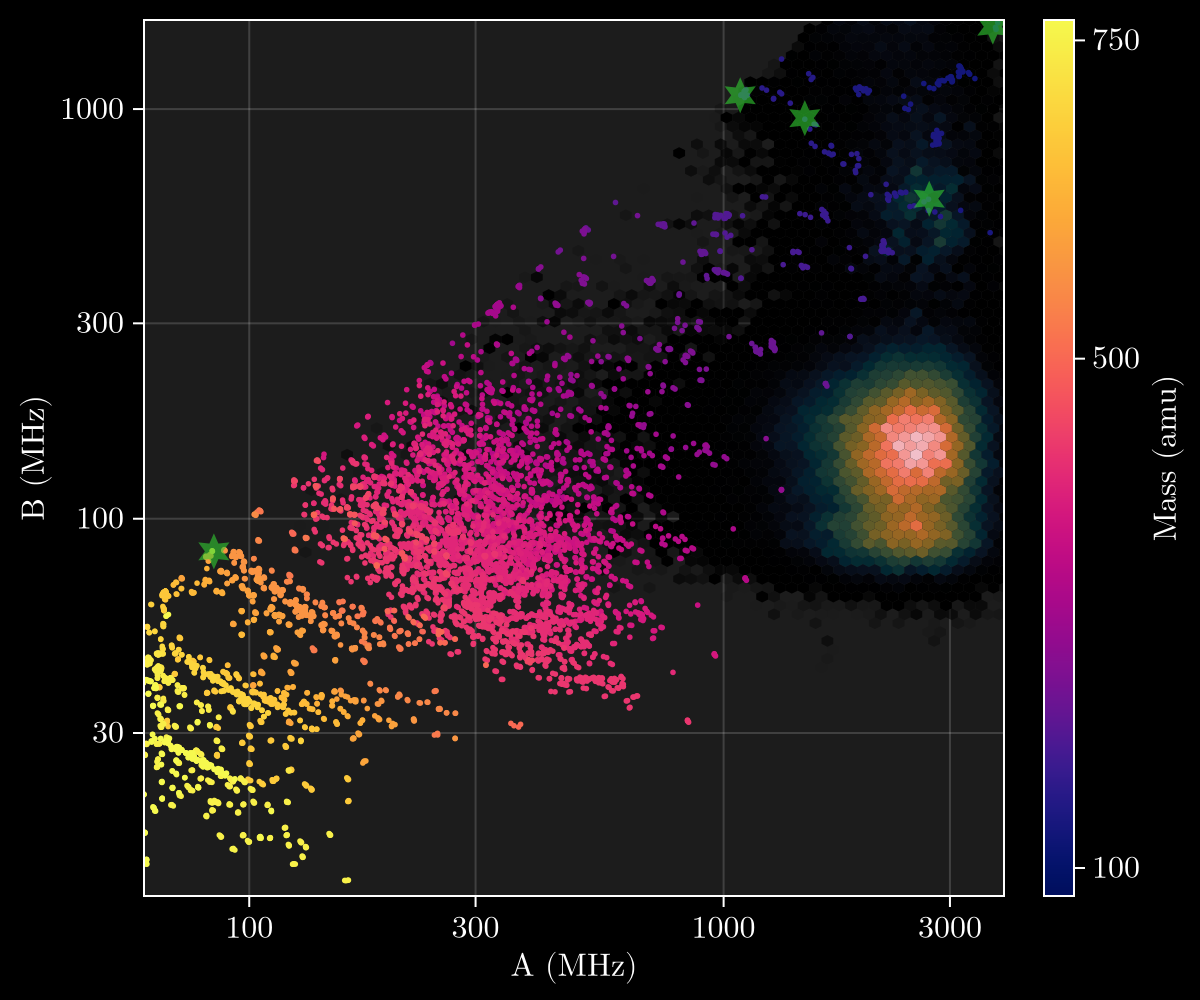

In [157]:
fig = Figure(size=(600, 500), fontsize=16,
    figure_padding=(10,10,10,10))
    
ax = Axis(fig[1, 1],
    xscale=log10,
    yscale=log10,
    xticks = [100, 300, 1000, 3000],
    yticks = [30, 100, 300, 1000],
    xlabel="A (MHz)",
    ylabel="B (MHz)",
    backgroundcolor = :grey11,
)

xlims!(ax,60,3900)
ylims!(ax,12,1650)

co = hexbin!(ax,A.*cm2MHz,B.*cm2MHz,
    cellsize = 0.025,
    threshold = 0.0,
    colormap = [Makie.to_color(:transparent); Makie.to_colormap(ColorSchemes.cmr_dusk)],
    # colorrange = (0,100),
)

co = scatter!(ax,ABCmat[1,.!msk]*cm2MHz,ABCmat[2,.!msk]*cm2MHz,color=Mmat[.!msk],
    colorrange=(78,766),
    colormap=ColorSchemes.linear_bmy_10_95_c71_n256, markersize=4)

scatter!(ax,ABCmat[1,msk]*cm2MHz,ABCmat[2,msk]*cm2MHz,color=("limegreen",0.6), marker=:star6, markersize=20)

Colorbar(fig[1, 2], co, width = 15, height = Relative(1), label="Mass (amu)", ticks=[100,500,750])

colgap!(fig.layout, 1, 20)

resize_to_layout!(fig)
fig

In [158]:
radio_const = Dict{String,Vector{Float64}}()
# https://ui.adsabs.harvard.edu/abs/2025A%26A...701L...8C/abstract
radio_const["phenalene"] = [1108.124, 1067.811, 545.856]
# https://ui.adsabs.harvard.edu/abs/2025ApJ...984L..36W/abstract
radio_const["cyanocoronene"] = [333.853, 221.2701, 133.1081]
# https://ui.adsabs.harvard.edu/abs/2021ApJ...913L..18B/abstract
radio_const["indene"] = [3775.038, 1580.8641, 1122.2484]
# https://ui.adsabs.harvard.edu/abs/2022ApJ...938L..12S/abstract
radio_const["2-cyanoindene"] = [3754.4, 675.991, 574.982]
# https://ui.adsabs.harvard.edu/abs/2021Sci...371.1265M/abstract
# https://ui.adsabs.harvard.edu/abs/2018MNRAS.476.5268M/abstract
radio_const["1-cyanonaphthalene"] = [1478.8483, 956.7842, 580.98898]
radio_const["2-cyanonaphthalene"] = [2707.0099, 606.0955, 495.2935]
# https://ui.adsabs.harvard.edu/abs/2024A%26A...690L..13C/abstract
radio_const["1-cyanoacenaphthylene"] = [1272.17, 647.279, 429.061]
radio_const["5-cyanoacenaphthylene"] = [1246.58, 690.18, 444.298]
# https://ui.adsabs.harvard.edu/abs/2024Sci...386..810W/abstract
# https://ui.adsabs.harvard.edu/abs/2025NatAs...9..262W/abstract
radio_const["1-cyanopyrene"] = [843.140, 372.5002, 258.4249]
radio_const["2-cyanopyrene"] = [1009.194, 313.1345, 239.0427]
radio_const["5-cyanopyrene"] = [651.3830, 453.7313, 267.5078];
# https://ui.adsabs.harvard.edu/abs/2018ApJS..239...17M/abstract
# useful, but all other molecules are too small and less relevant

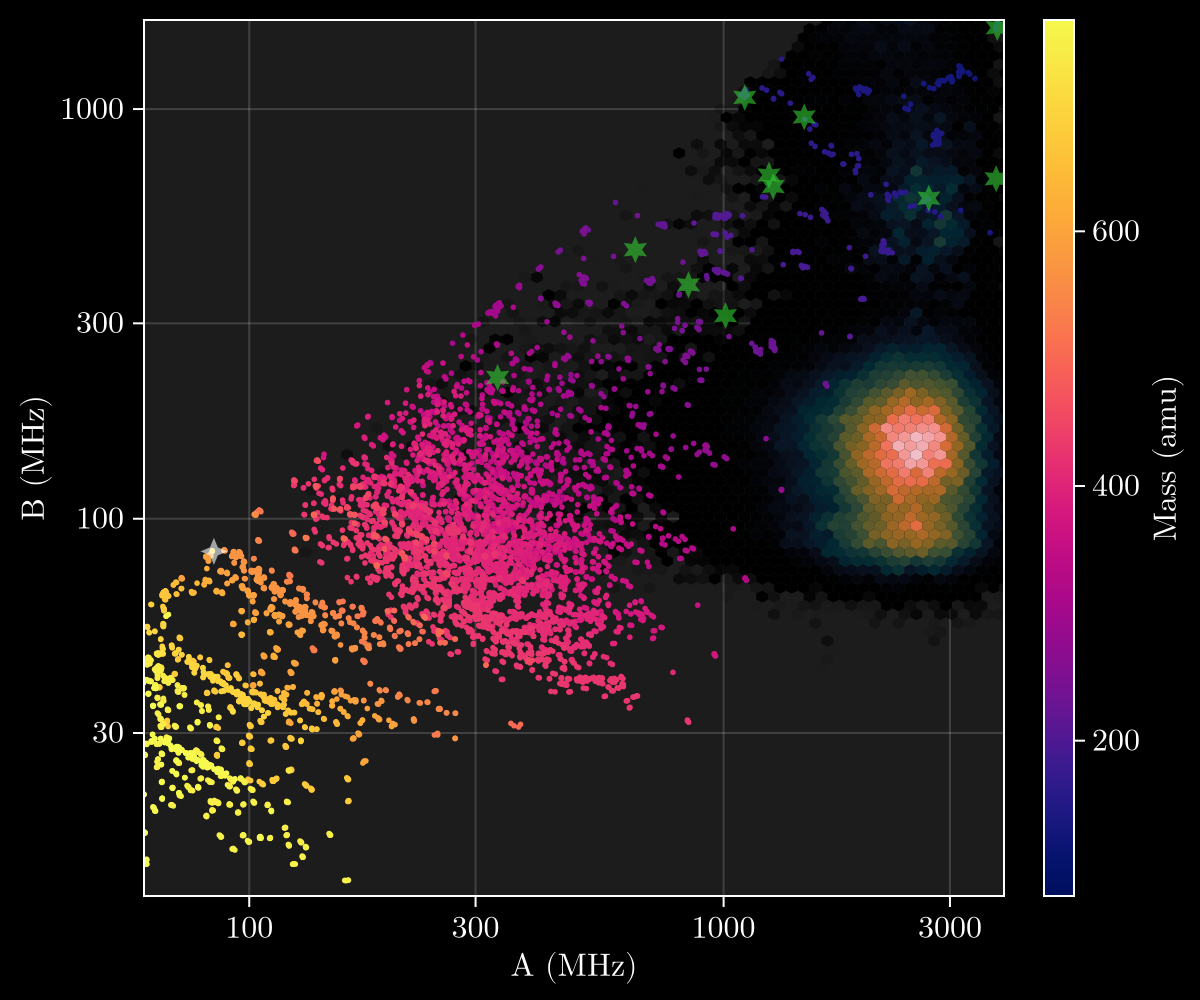

In [159]:
fig = Figure(size=(600, 500), fontsize=16,
    figure_padding=(10,10,10,10))
    
ax = Axis(fig[1, 1],
    xscale=log10,
    yscale=log10,
    xticks = [100, 300, 1000, 3000],
    yticks = [30, 100, 300, 1000],
    xlabel="A (MHz)",
    ylabel="B (MHz)",
    backgroundcolor = :grey11,
)

xlims!(ax,60,3900)
ylims!(ax,12,1650)

co = hexbin!(ax,A.*cm2MHz,B.*cm2MHz,
    cellsize = 0.025,
    threshold = 0.0,
    colormap = [Makie.to_color(:transparent); Makie.to_colormap(ColorSchemes.cmr_dusk)],
    # colorrange = (0,100),
)

co = scatter!(ax,ABCmat[1,.!msk]*cm2MHz,ABCmat[2,.!msk]*cm2MHz,color=Mmat[.!msk],
    colorrange=(78,766),
    colormap=ColorSchemes.linear_bmy_10_95_c71_n256, markersize=4)

for key in keys(radio_const)
    scatter!(ax,radio_const[key][1],radio_const[key][2],color=("limegreen",0.6), marker=:star6, markersize=15)
end
tindx = findall(map(x->x.uid, entries) .== 720) # C60+
scatter!(ax,ABCmat[1,tindx]*cm2MHz,ABCmat[2,tindx]*cm2MHz,color=("white",0.6), marker=:star4, markersize=15)

Colorbar(fig[1, 2], co, width = 15, height = Relative(1), label="Mass (amu)", ticks=[200,400,600])

colgap!(fig.layout, 1, 20)

resize_to_layout!(fig)
fig

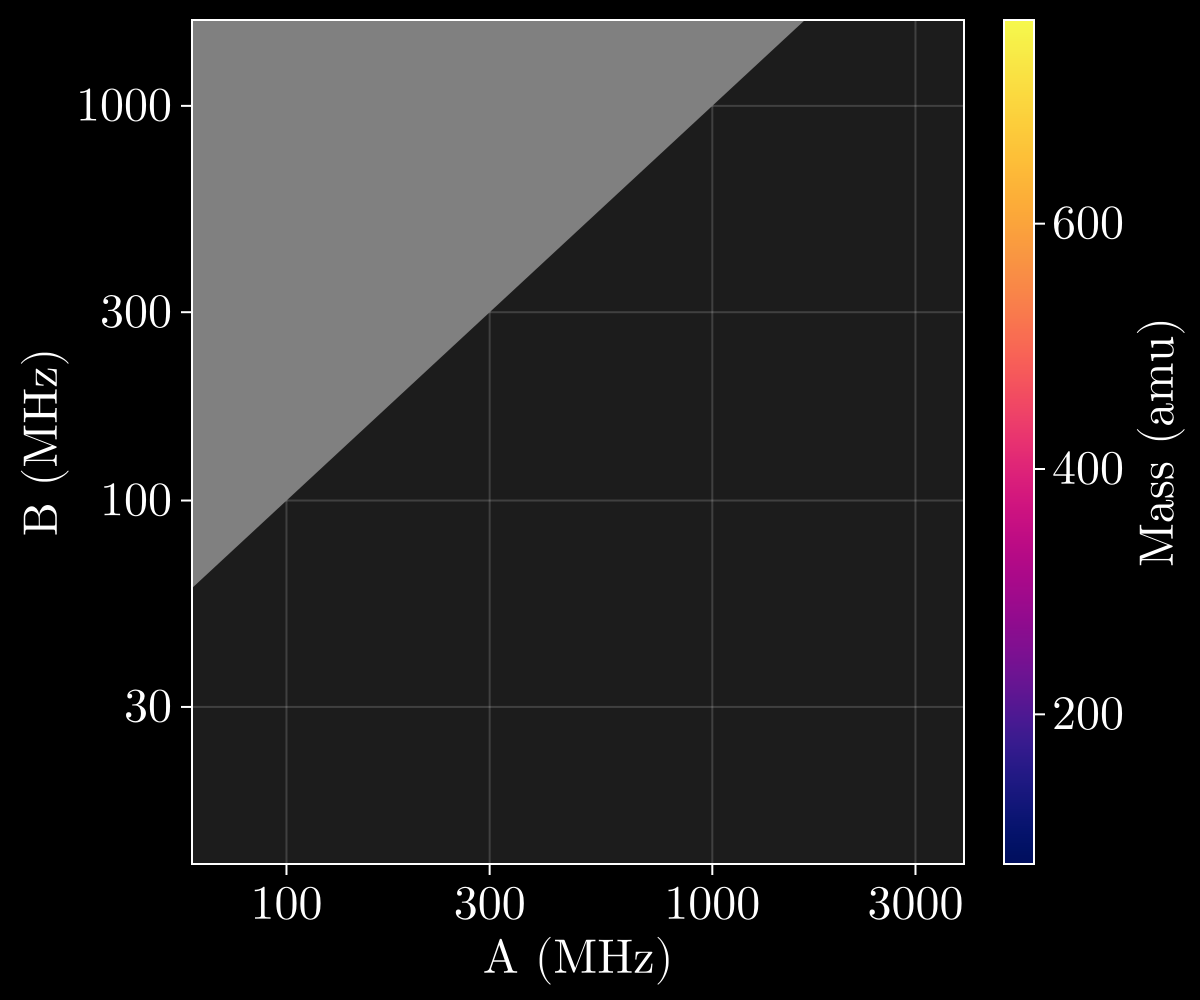

In [160]:
fig = Figure(size=(600, 500), fontsize=24,
    figure_padding=(10,10,10,10))
    
ax = Axis(fig[1, 1],
    xscale=log10,
    yscale=log10,
    xticks = [100, 300, 1000, 3000],
    yticks = [30, 100, 300, 1000],
    xlabel="A (MHz)",
    ylabel="B (MHz)",
    backgroundcolor = :grey11,
)

xlims!(ax,60,3900)
ylims!(ax,12,1650)

# Shade region where B > A
x_band = [60, 1650, 3900]
y_lower = [60, 1650, 1650]  # The B=A diagonal line extended
y_upper = [1650, 1650, 1650]  # The top of the plot
band!(ax, x_band, y_lower, y_upper, color=(:grey, 1))

# co = hexbin!(ax,A.*cm2MHz,B.*cm2MHz,
#     cellsize = 0.025,
#     threshold = 0.0,
#     colormap = [Makie.to_color(:transparent); Makie.to_colormap(ColorSchemes.cmr_dusk)],
#     # colorrange = (0,100),
# )

# co = scatter!(ax,ABCmat[1,.!msk]*cm2MHz,ABCmat[2,.!msk]*cm2MHz,color=Mmat[.!msk],
#     colorrange=(78,766),
#     colormap=ColorSchemes.linear_bmy_10_95_c71_n256, markersize=4)

# for key in keys(radio_const)
#     scatter!(ax,radio_const[key][1],radio_const[key][2],color=("limegreen",0.6), marker=:star6, markersize=15)
# end
# tindx = findall(map(x->x.uid, entries) .== 720) # C60+
# scatter!(ax,ABCmat[1,tindx]*cm2MHz,ABCmat[2,tindx]*cm2MHz,color=("white",0.6), marker=:star4, markersize=15)

Colorbar(fig[1, 2], co, width = 15, height = Relative(1), label="Mass (amu)", ticks=[200,400,600])

colgap!(fig.layout, 1, 20)

resize_to_layout!(fig)
fig

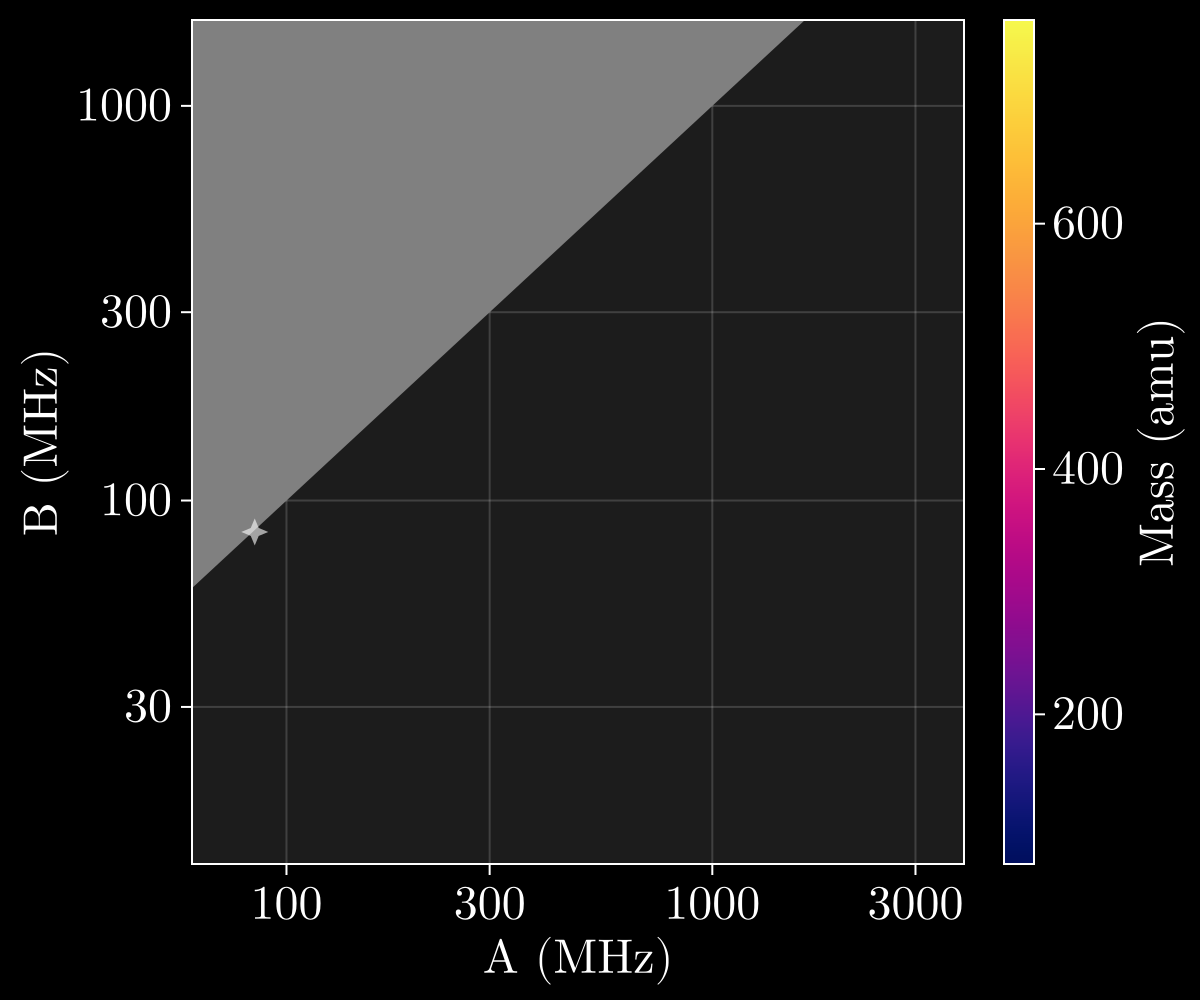

In [105]:
fig = Figure(size=(600, 500), fontsize=24,
    figure_padding=(10,10,10,10))
    
ax = Axis(fig[1, 1],
    xscale=log10,
    yscale=log10,
    xticks = [100, 300, 1000, 3000],
    yticks = [30, 100, 300, 1000],
    xlabel="A (MHz)",
    ylabel="B (MHz)",
    backgroundcolor = :grey11,
)

xlims!(ax,60,3900)
ylims!(ax,12,1650)

# Shade region where B > A
x_band = [60, 1650, 3900]
y_lower = [60, 1650, 1650]  # The B=A diagonal line extended
y_upper = [1650, 1650, 1650]  # The top of the plot
band!(ax, x_band, y_lower, y_upper, color=(:grey, 1))

# co = hexbin!(ax,A.*cm2MHz,B.*cm2MHz,
#     cellsize = 0.025,
#     threshold = 0.0,
#     colormap = [Makie.to_color(:transparent); Makie.to_colormap(ColorSchemes.cmr_dusk)],
#     # colorrange = (0,100),
# )

# co = scatter!(ax,ABCmat[1,.!msk]*cm2MHz,ABCmat[2,.!msk]*cm2MHz,color=Mmat[.!msk],
#     colorrange=(78,766),
#     colormap=ColorSchemes.linear_bmy_10_95_c71_n256, markersize=4)

# for key in keys(radio_const)
#     scatter!(ax,radio_const[key][1],radio_const[key][2],color=("limegreen",0.6), marker=:star6, markersize=15)
# end
tindx = findall(map(x->x.uid, entries) .== 720) # C60+
scatter!(ax,ABCmat[1,tindx]*cm2MHz,ABCmat[2,tindx]*cm2MHz,color=("white",0.6), marker=:star4, markersize=15)

Colorbar(fig[1, 2], co, width = 15, height = Relative(1), label="Mass (amu)", ticks=[200,400,600])

colgap!(fig.layout, 1, 20)

resize_to_layout!(fig)
fig

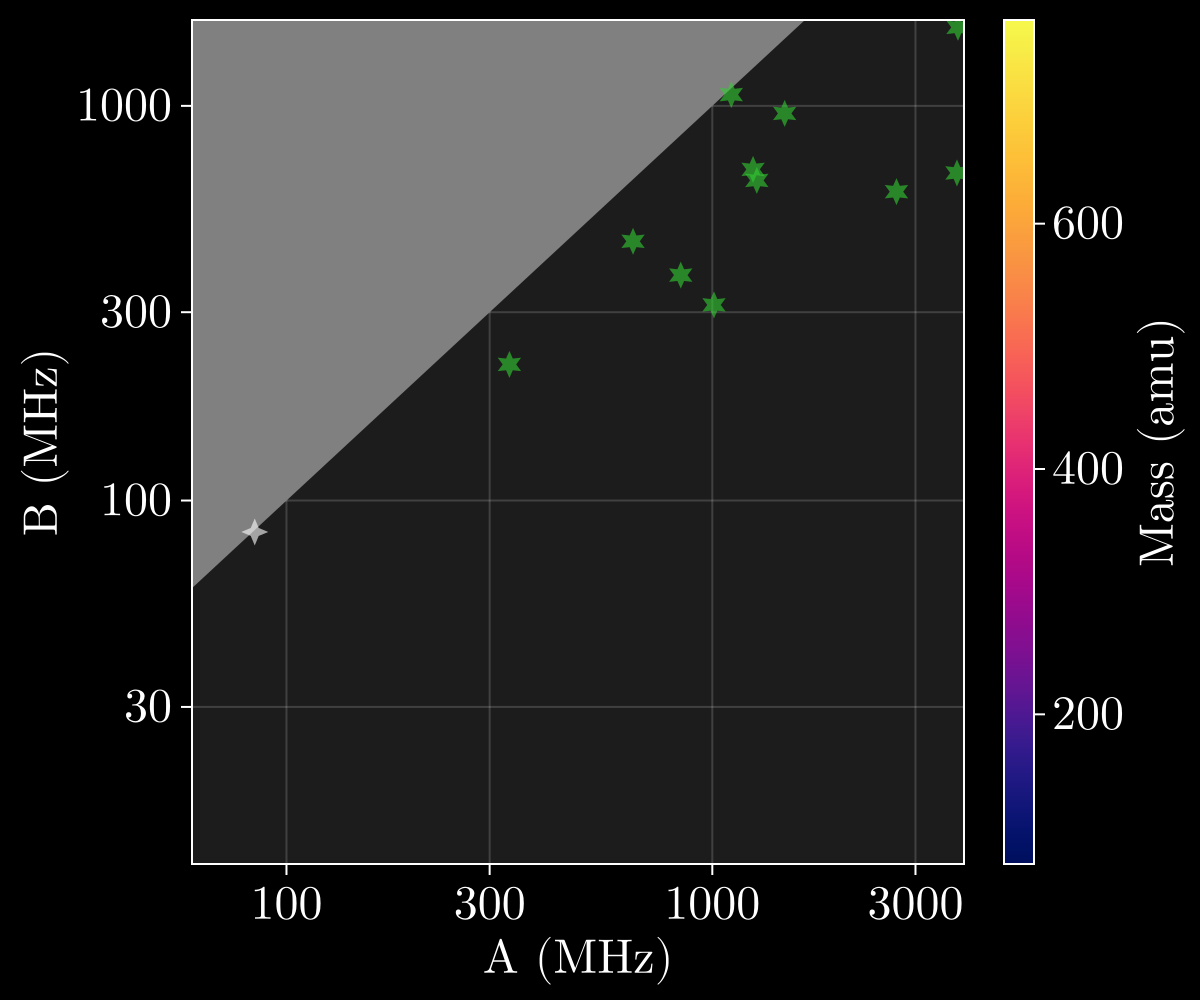

In [106]:
fig = Figure(size=(600, 500), fontsize=24,
    figure_padding=(10,10,10,10))
    
ax = Axis(fig[1, 1],
    xscale=log10,
    yscale=log10,
    xticks = [100, 300, 1000, 3000],
    yticks = [30, 100, 300, 1000],
    xlabel="A (MHz)",
    ylabel="B (MHz)",
    backgroundcolor = :grey11,
)

xlims!(ax,60,3900)
ylims!(ax,12,1650)

# Shade region where B > A
x_band = [60, 1650, 3900]
y_lower = [60, 1650, 1650]  # The B=A diagonal line extended
y_upper = [1650, 1650, 1650]  # The top of the plot
band!(ax, x_band, y_lower, y_upper, color=(:grey, 1))

# co = hexbin!(ax,A.*cm2MHz,B.*cm2MHz,
#     cellsize = 0.025,
#     threshold = 0.0,
#     colormap = [Makie.to_color(:transparent); Makie.to_colormap(ColorSchemes.cmr_dusk)],
#     # colorrange = (0,100),
# )

# co = scatter!(ax,ABCmat[1,.!msk]*cm2MHz,ABCmat[2,.!msk]*cm2MHz,color=Mmat[.!msk],
#     colorrange=(78,766),
#     colormap=ColorSchemes.linear_bmy_10_95_c71_n256, markersize=4)

for key in keys(radio_const)
    scatter!(ax,radio_const[key][1],radio_const[key][2],color=("limegreen",0.6), marker=:star6, markersize=15)
end
tindx = findall(map(x->x.uid, entries) .== 720) # C60+
scatter!(ax,ABCmat[1,tindx]*cm2MHz,ABCmat[2,tindx]*cm2MHz,color=("white",0.6), marker=:star4, markersize=15)

Colorbar(fig[1, 2], co, width = 15, height = Relative(1), label="Mass (amu)", ticks=[200,400,600])

colgap!(fig.layout, 1, 20)

resize_to_layout!(fig)
fig

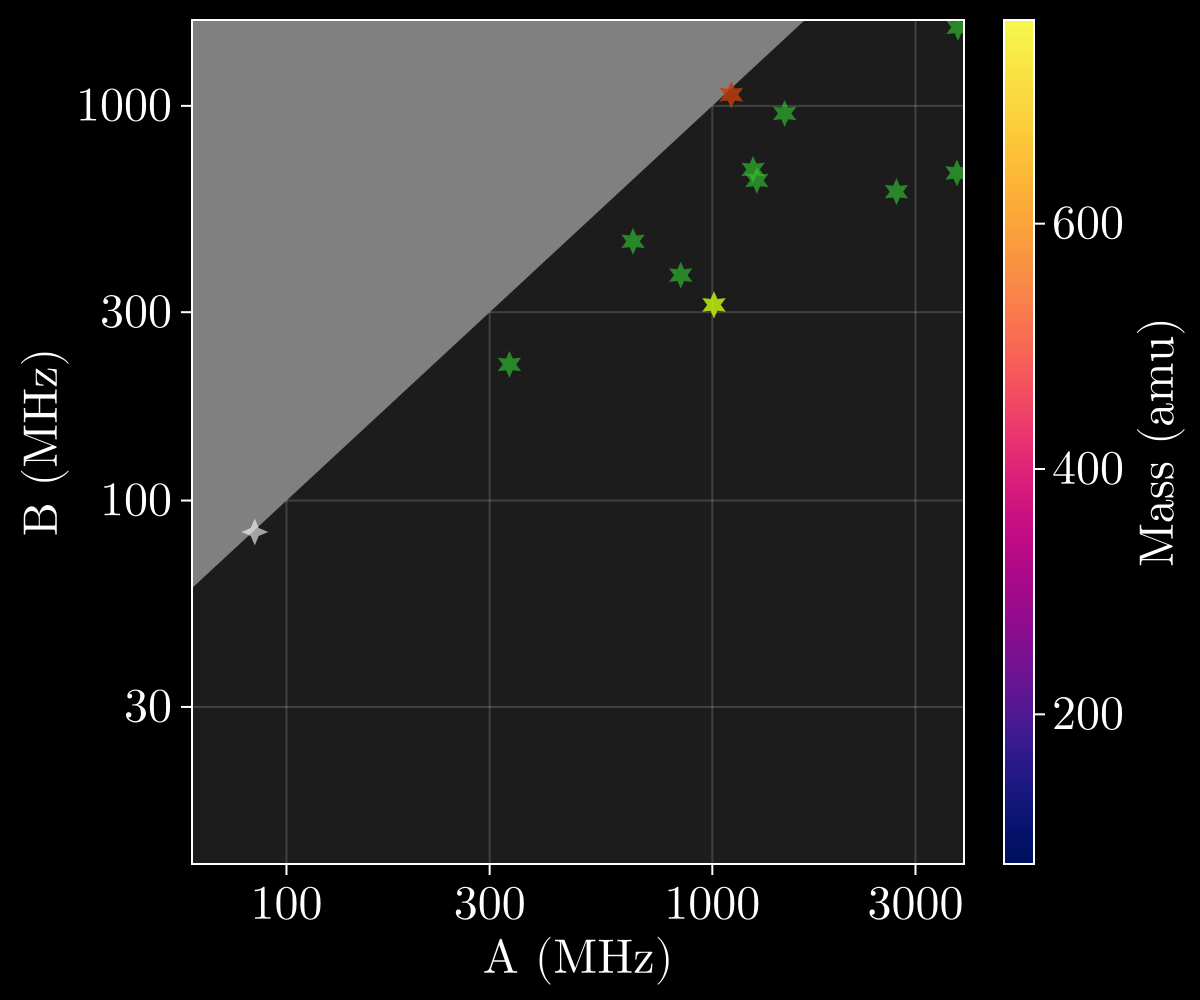

In [107]:
fig = Figure(size=(600, 500), fontsize=24,
    figure_padding=(10,10,10,10))
    
ax = Axis(fig[1, 1],
    xscale=log10,
    yscale=log10,
    xticks = [100, 300, 1000, 3000],
    yticks = [30, 100, 300, 1000],
    xlabel="A (MHz)",
    ylabel="B (MHz)",
    backgroundcolor = :grey11,
)

xlims!(ax,60,3900)
ylims!(ax,12,1650)

# Shade region where B > A
x_band = [60, 1650, 3900]
y_lower = [60, 1650, 1650]  # The B=A diagonal line extended
y_upper = [1650, 1650, 1650]  # The top of the plot
band!(ax, x_band, y_lower, y_upper, color=(:grey, 1))

# co = hexbin!(ax,A.*cm2MHz,B.*cm2MHz,
#     cellsize = 0.025,
#     threshold = 0.0,
#     colormap = [Makie.to_color(:transparent); Makie.to_colormap(ColorSchemes.cmr_dusk)],
#     # colorrange = (0,100),
# )

# co = scatter!(ax,ABCmat[1,.!msk]*cm2MHz,ABCmat[2,.!msk]*cm2MHz,color=Mmat[.!msk],
#     colorrange=(78,766),
#     colormap=ColorSchemes.linear_bmy_10_95_c71_n256, markersize=4)

for key in keys(radio_const)
    scatter!(ax,radio_const[key][1],radio_const[key][2],color=("limegreen",0.6), marker=:star6, markersize=15)
end
tindx = findall(map(x->x.uid, entries) .== 720) # C60+
scatter!(ax,ABCmat[1,tindx]*cm2MHz,ABCmat[2,tindx]*cm2MHz,color=("white",0.6), marker=:star4, markersize=15)
key = "phenalene"
scatter!(ax,radio_const[key][1],radio_const[key][2],color=("red",0.6), marker=:star6, markersize=15)
key = "2-cyanopyrene"
scatter!(ax,radio_const[key][1],radio_const[key][2],color=("yellow",0.6), marker=:star6, markersize=15)

Colorbar(fig[1, 2], co, width = 15, height = Relative(1), label="Mass (amu)", ticks=[200,400,600])

colgap!(fig.layout, 1, 20)

resize_to_layout!(fig)
fig

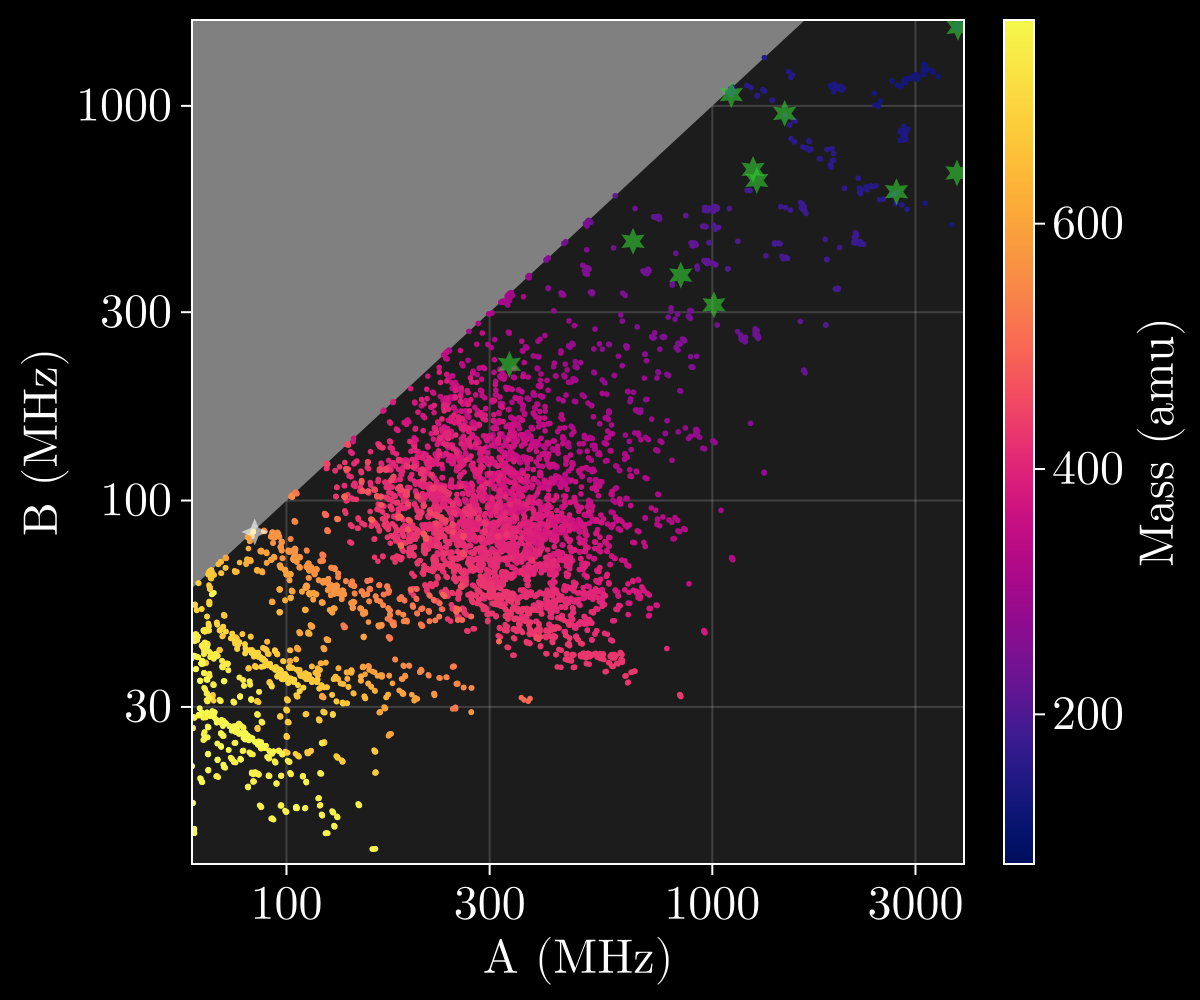

In [108]:
fig = Figure(size=(600, 500), fontsize=24,
    figure_padding=(10,10,10,10))
    
ax = Axis(fig[1, 1],
    xscale=log10,
    yscale=log10,
    xticks = [100, 300, 1000, 3000],
    yticks = [30, 100, 300, 1000],
    xlabel="A (MHz)",
    ylabel="B (MHz)",
    backgroundcolor = :grey11,
)

xlims!(ax,60,3900)
ylims!(ax,12,1650)

# Shade region where B > A
x_band = [60, 1650, 3900]
y_lower = [60, 1650, 1650]  # The B=A diagonal line extended
y_upper = [1650, 1650, 1650]  # The top of the plot
band!(ax, x_band, y_lower, y_upper, color=(:grey, 1))

# co = hexbin!(ax,A.*cm2MHz,B.*cm2MHz,
#     cellsize = 0.025,
#     threshold = 0.0,
#     colormap = [Makie.to_color(:transparent); Makie.to_colormap(ColorSchemes.cmr_dusk)],
#     # colorrange = (0,100),
# )

co = scatter!(ax,ABCmat[1,.!msk]*cm2MHz,ABCmat[2,.!msk]*cm2MHz,color=Mmat[.!msk],
    colorrange=(78,766),
    colormap=ColorSchemes.linear_bmy_10_95_c71_n256, markersize=4)

for key in keys(radio_const)
    scatter!(ax,radio_const[key][1],radio_const[key][2],color=("limegreen",0.6), marker=:star6, markersize=15)
end
tindx = findall(map(x->x.uid, entries) .== 720) # C60+
scatter!(ax,ABCmat[1,tindx]*cm2MHz,ABCmat[2,tindx]*cm2MHz,color=("white",0.6), marker=:star4, markersize=15)

Colorbar(fig[1, 2], co, width = 15, height = Relative(1), label="Mass (amu)", ticks=[200,400,600])

colgap!(fig.layout, 1, 20)

resize_to_layout!(fig)
fig

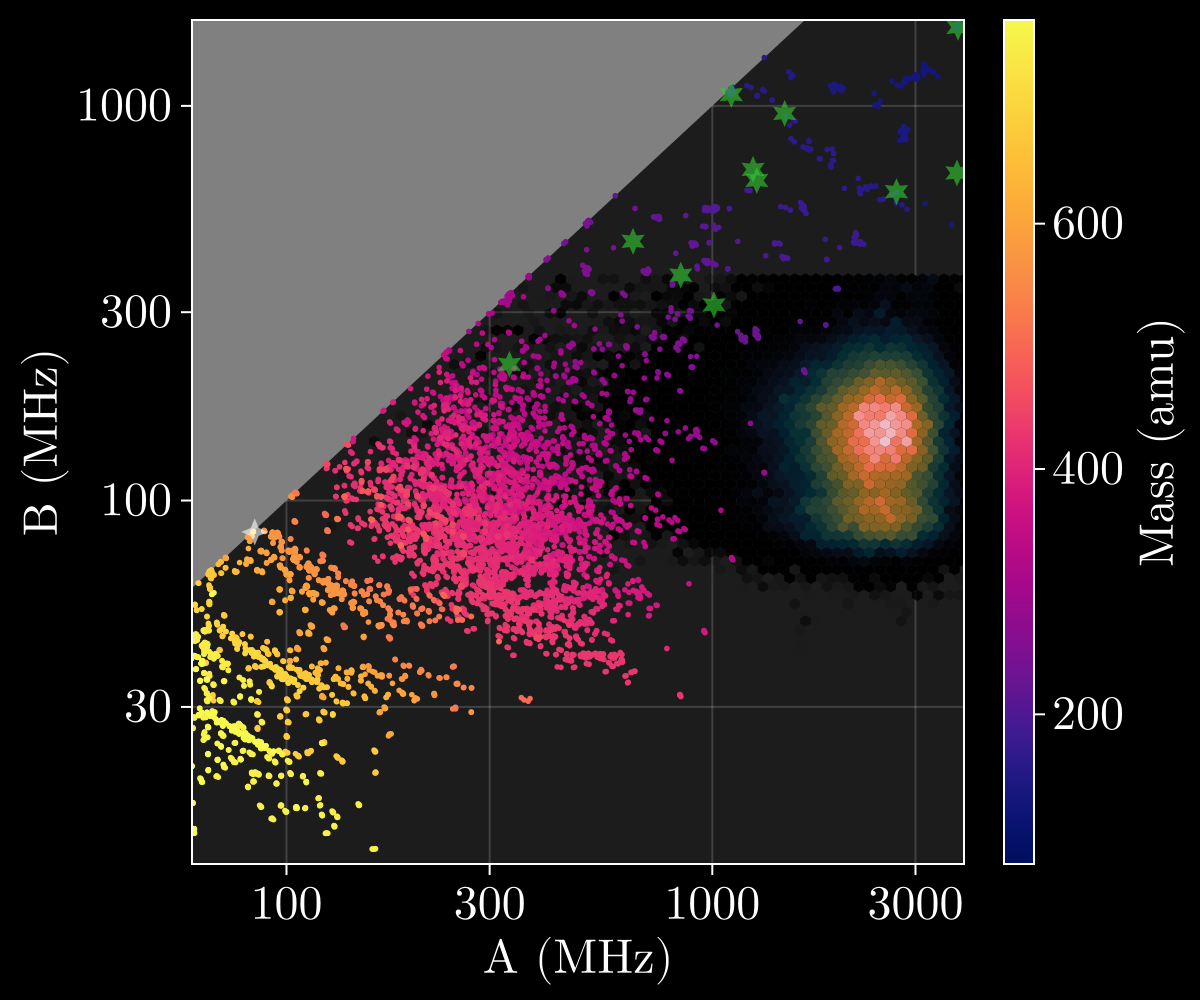

In [109]:
fig = Figure(size=(600, 500), fontsize=24,
    figure_padding=(10,10,10,10))
    
ax = Axis(fig[1, 1],
    xscale=log10,
    yscale=log10,
    xticks = [100, 300, 1000, 3000],
    yticks = [30, 100, 300, 1000],
    xlabel="A (MHz)",
    ylabel="B (MHz)",
    backgroundcolor = :grey11,
)

xlims!(ax,60,3900)
ylims!(ax,12,1650)

# Shade region where B > A
x_band = [60, 1650, 3900]
y_lower = [60, 1650, 1650]  # The B=A diagonal line extended
y_upper = [1650, 1650, 1650]  # The top of the plot
band!(ax, x_band, y_lower, y_upper, color=(:grey, 1))

co = hexbin!(ax,A.*cm2MHz,B.*cm2MHz,
    cellsize = 0.025,
    threshold = 0.0,
    colormap = [Makie.to_color(:transparent); Makie.to_colormap(ColorSchemes.cmr_dusk)],
    # colorrange = (0,100),
)

co = scatter!(ax,ABCmat[1,.!msk]*cm2MHz,ABCmat[2,.!msk]*cm2MHz,color=Mmat[.!msk],
    colorrange=(78,766),
    colormap=ColorSchemes.linear_bmy_10_95_c71_n256, markersize=4)

for key in keys(radio_const)
    scatter!(ax,radio_const[key][1],radio_const[key][2],color=("limegreen",0.6), marker=:star6, markersize=15)
end
tindx = findall(map(x->x.uid, entries) .== 720) # C60+
scatter!(ax,ABCmat[1,tindx]*cm2MHz,ABCmat[2,tindx]*cm2MHz,color=("white",0.6), marker=:star4, markersize=15)

Colorbar(fig[1, 2], co, width = 15, height = Relative(1), label="Mass (amu)", ticks=[200,400,600])

colgap!(fig.layout, 1, 20)

resize_to_layout!(fig)
fig

In [110]:
radio_const

Dict{String, Vector{Float64}} with 11 entries:
  "5-cyanoacenaphthylene" => [1246.58, 690.18, 444.298]
  "2-cyanopyrene"         => [1009.19, 313.135, 239.043]
  "5-cyanopyrene"         => [651.383, 453.731, 267.508]
  "cyanocoronene"         => [333.853, 221.27, 133.108]
  "phenalene"             => [1108.12, 1067.81, 545.856]
  "2-cyanonaphthalene"    => [2707.01, 606.096, 495.293]
  "1-cyanonaphthalene"    => [1478.85, 956.784, 580.989]
  "1-cyanopyrene"         => [843.14, 372.5, 258.425]
  "2-cyanoindene"         => [3754.4, 675.991, 574.982]
  "1-cyanoacenaphthylene" => [1272.17, 647.279, 429.061]
  "indene"                => [3775.04, 1580.86, 1122.25]

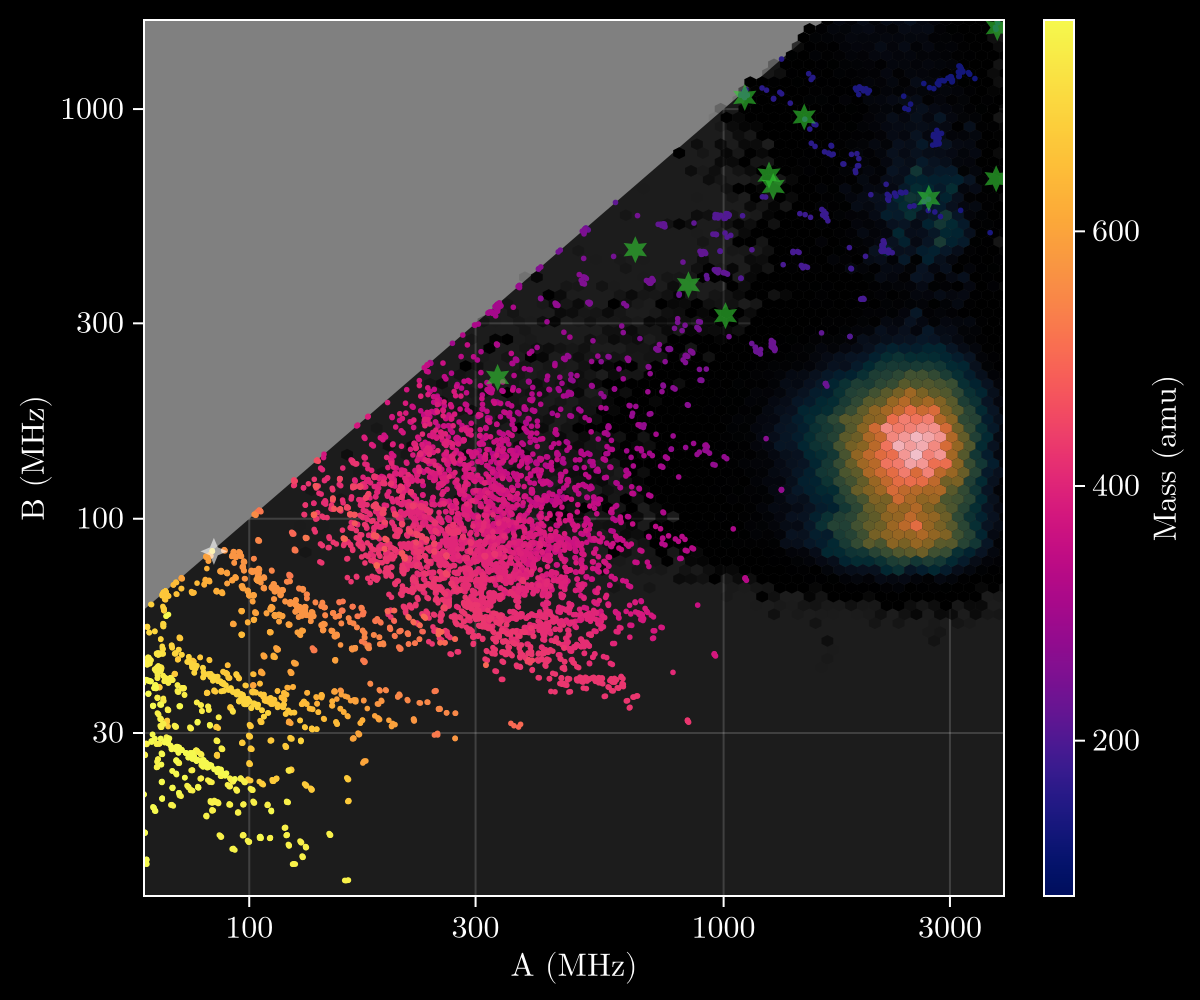

In [164]:
fig = Figure(size=(600, 500), fontsize=16,
    figure_padding=(10,10,10,10))
    
ax = Axis(fig[1, 1],
    xscale=log10,
    yscale=log10,
    xticks = [100, 300, 1000, 3000],
    yticks = [30, 100, 300, 1000],
    xlabel="A (MHz)",
    ylabel="B (MHz)",
    backgroundcolor = :grey11,
)

xlims!(ax,60,3900)
ylims!(ax,12,1650)

# Shade region where B > A
x_band = [60, 1650, 3900]
y_lower = [60, 1650, 1650]  # The B=A diagonal line extended
y_upper = [1650, 1650, 1650]  # The top of the plot
band!(ax, x_band, y_lower, y_upper, color=(:grey, 1))

co = hexbin!(ax,A.*cm2MHz,B.*cm2MHz,
    cellsize = 0.025,
    threshold = 0.0,
    colormap = [Makie.to_color(:transparent); Makie.to_colormap(ColorSchemes.cmr_dusk)],
    # colorrange = (0,100),
)

co = scatter!(ax,ABCmat[1,.!msk]*cm2MHz,ABCmat[2,.!msk]*cm2MHz,color=Mmat[.!msk],
    colorrange=(78,766),
    colormap=ColorSchemes.linear_bmy_10_95_c71_n256, markersize=4)

for key in keys(radio_const)
    scatter!(ax,radio_const[key][1],radio_const[key][2],color=("limegreen",0.6), marker=:star6, markersize=15)
end
tindx = findall(map(x->x.uid, entries) .== 720) # C60+
scatter!(ax,ABCmat[1,tindx]*cm2MHz,ABCmat[2,tindx]*cm2MHz,color=("white",0.6), marker=:star4, markersize=15)

Colorbar(fig[1, 2], co, width = 15, height = Relative(1), label="Mass (amu)", ticks=[200,400,600])

colgap!(fig.layout, 1, 20)

resize_to_layout!(fig)
fig

choose to cut off one prolate radio PAH

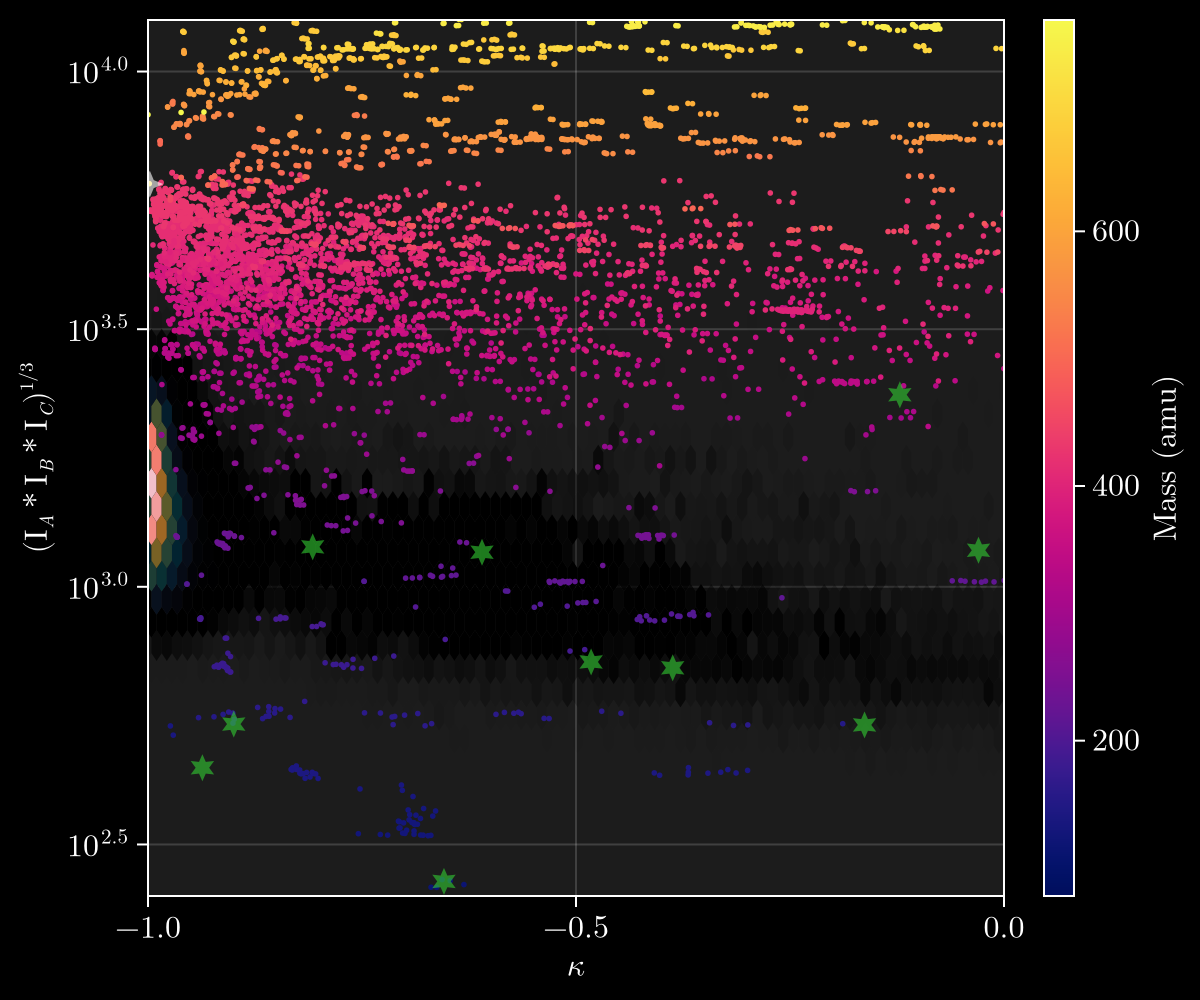

In [163]:
fig = Figure(size=(600, 500), fontsize=16,
    figure_padding=(10,10,10,10))
ax = Axis(fig[1, 1],
    # xscale=Makie.pseudolog10,
    yscale=log10,
    # xticks = [5e-4,5e-3],
    # yticks = [5e-4,1e-4,5e-3,1e-2,5e-2],
    xlabel=L"$\kappa$",
    ylabel=L"(I$_A$*I$_B$*I$_C$)$^{1/3}$",
    backgroundcolor = :grey11,
)

xlims!(ax,-1,0)
ylims!(ax,10^(2.4),10^(4.1))

co = hexbin!(ax,kap_vec_post,Iprod_post.^(1/3),
    cellsize = (0.012,0.06),
    threshold = 0.0,
    colormap = [Makie.to_color(:transparent); Makie.to_colormap(ColorSchemes.cmr_dusk)],
    # colorrange = (0,100),
)

co = scatter!(ax,kap_vec[.!msk],Iprod[.!msk].^(1/3),color=Mmat[.!msk],
    colorrange=(78,766),
    colormap=ColorSchemes.linear_bmy_10_95_c71_n256, markersize=4)
for key in keys(radio_const)
    scatter!(ax,rasym_param(radio_const[key][1]/cm2MHz,radio_const[key][2]/cm2MHz,radio_const[key][3]/cm2MHz),get_iprod(radio_const[key][1]/cm2MHz,radio_const[key][2]/cm2MHz,radio_const[key][3]/cm2MHz).^(1/3),color=("limegreen",0.6), marker=:star6, markersize=15)
end
tindx = findall(map(x->x.uid, entries) .== 720) # C60+
scatter!(ax,rasym_param.(ABCmat[1,tindx],ABCmat[2,tindx],ABCmat[3,tindx]),get_iprod.(ABCmat[1,tindx],ABCmat[2,tindx],ABCmat[3,tindx]).^(1/3),color=("white",0.6), marker=:star4, markersize=15)

Colorbar(fig[1, 2], co, width = 15, height = Relative(1), label="Mass (amu)", ticks=[200,400,600])

colgap!(fig.layout, 1, 20)

resize_to_layout!(fig)
fig

In [114]:
maximum( (ABCmat[2,.!msk].-ABCmat[3,.!msk])./ABCmat[2,.!msk])

0.49999999920986865

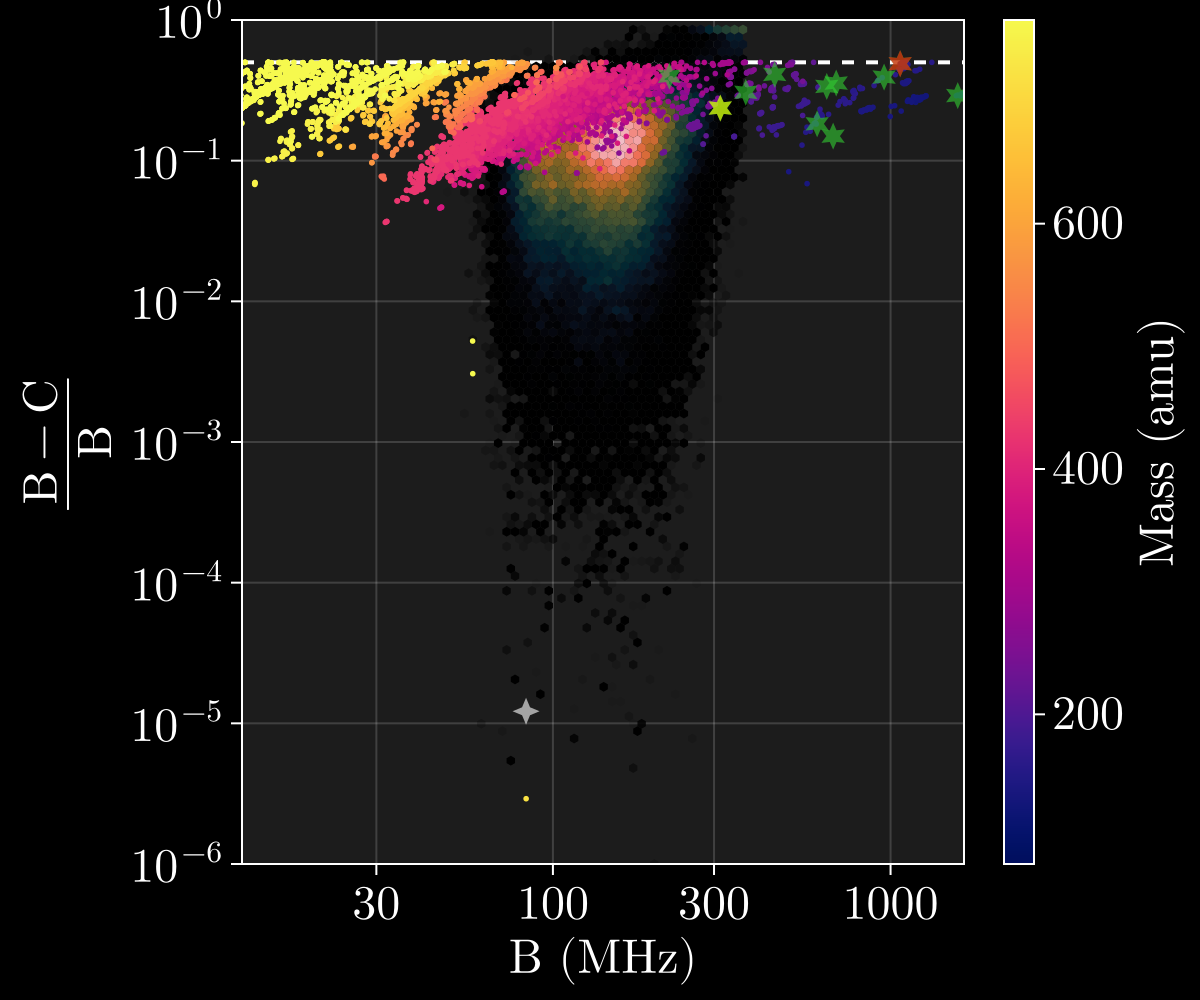

In [119]:
fig = Figure(size=(600, 500), fontsize=24,
    figure_padding=(10,10,10,10))
    
ax = Axis(fig[1, 1],
    xscale=log10,
    yscale=log10,
    xticks = [30, 100, 300, 1000],
    # yticks = [1e-5,5e-4,1e-4,2e-3,1e-2,5e-2],
    xlabel="B (MHz)",
    ylabel=L"\frac{\text{B-C}}{\text{B}}",
    backgroundcolor = :grey11,
)

xlims!(ax,12,1650)
ylims!(ax,1e-6,1e0)
# Explanation of why (B-C)/B cannot be above 0.5, if C < 0.5 B then (B-C)/B>0.5
hlines!(ax, 0.5, color=:white, linewidth=2, linestyle=:dash)

co = hexbin!(ax,B.*cm2MHz, (B.-C)./B,
    cellsize = (0.025,0.07),
    threshold = 0.0,
    colormap = [Makie.to_color(:transparent); Makie.to_colormap(ColorSchemes.cmr_dusk)],
    # colorrange = (0,100),
)

co = scatter!(ax,ABCmat[2,.!msk].*cm2MHz, (ABCmat[2,.!msk].-ABCmat[3,.!msk])./ABCmat[2,.!msk],color=Mmat[.!msk],
    colorrange=(78,766),
    colormap=ColorSchemes.linear_bmy_10_95_c71_n256, markersize=4)

for key in keys(radio_const)
    scatter!(ax,radio_const[key][2],(radio_const[key][2].-radio_const[key][3])./radio_const[key][2],color=("limegreen",0.6), marker=:star6, markersize=15)
end
tindx = findall(map(x->x.uid, entries) .== 720) # C60+
scatter!(ax,ABCmat[2,tindx].*cm2MHz,(ABCmat[2,tindx].-ABCmat[3,tindx])./ABCmat[2,tindx],color=("white",0.6), marker=:star4, markersize=15)

key = "phenalene"
scatter!(ax,radio_const[key][2],(radio_const[key][2].-radio_const[key][3])./radio_const[key][2],color=("red",0.6), marker=:star6, markersize=15)
key = "2-cyanopyrene"
scatter!(ax,radio_const[key][2],(radio_const[key][2].-radio_const[key][3])./radio_const[key][2],color=("yellow",0.6), marker=:star6, markersize=15)

Colorbar(fig[1, 2], co, width = 15, height = Relative(1), label="Mass (amu)", ticks=[200,400,600])

colgap!(fig.layout, 1, 20)

resize_to_layout!(fig)
fig

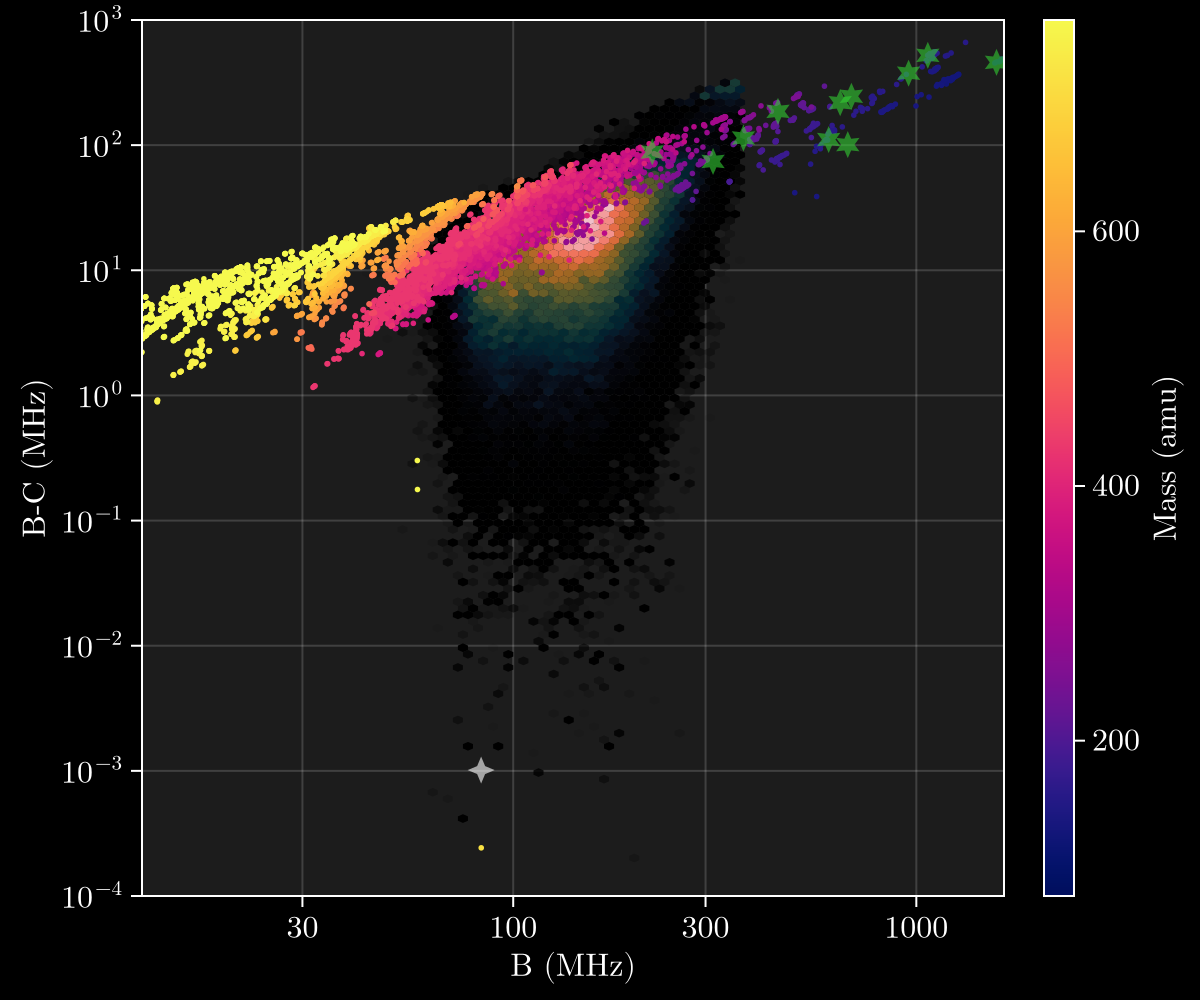

In [116]:
fig = Figure(size=(600, 500), fontsize=16,
    figure_padding=(10,10,10,10))
    
ax = Axis(fig[1, 1],
    xscale=log10,
    yscale=log10,
    xticks = [30, 100, 300, 1000],
    # yticks = [1e-5,5e-4,1e-4,2e-3,1e-2,5e-2],
    xlabel="B (MHz)",
    ylabel="B-C (MHz)",
    backgroundcolor = :grey11,
)

xlims!(ax,12,1650)
ylims!(ax,1e-4,1e3)

co = hexbin!(ax,B.*cm2MHz, (B.-C).*cm2MHz,
    cellsize = (0.025,0.07),
    threshold = 0.0,
    colormap = [Makie.to_color(:transparent); Makie.to_colormap(ColorSchemes.cmr_dusk)],
    # colorrange = (0,100),
)

co = scatter!(ax,ABCmat[2,.!msk].*cm2MHz, (ABCmat[2,.!msk].-ABCmat[3,.!msk]).*cm2MHz,color=Mmat[.!msk],
    colorrange=(78,766),
    colormap=ColorSchemes.linear_bmy_10_95_c71_n256, markersize=4)

for key in keys(radio_const)
    scatter!(ax,radio_const[key][2],(radio_const[key][2].-radio_const[key][3]),color=("limegreen",0.6), marker=:star6, markersize=15)
end
tindx = findall(map(x->x.uid, entries) .== 720) # C60+
scatter!(ax,ABCmat[2,tindx].*cm2MHz,(ABCmat[2,tindx].-ABCmat[3,tindx]).*cm2MHz,color=("white",0.6), marker=:star4, markersize=15)

Colorbar(fig[1, 2], co, width = 15, height = Relative(1), label="Mass (amu)", ticks=[200,400,600])

colgap!(fig.layout, 1, 20)

resize_to_layout!(fig)
fig

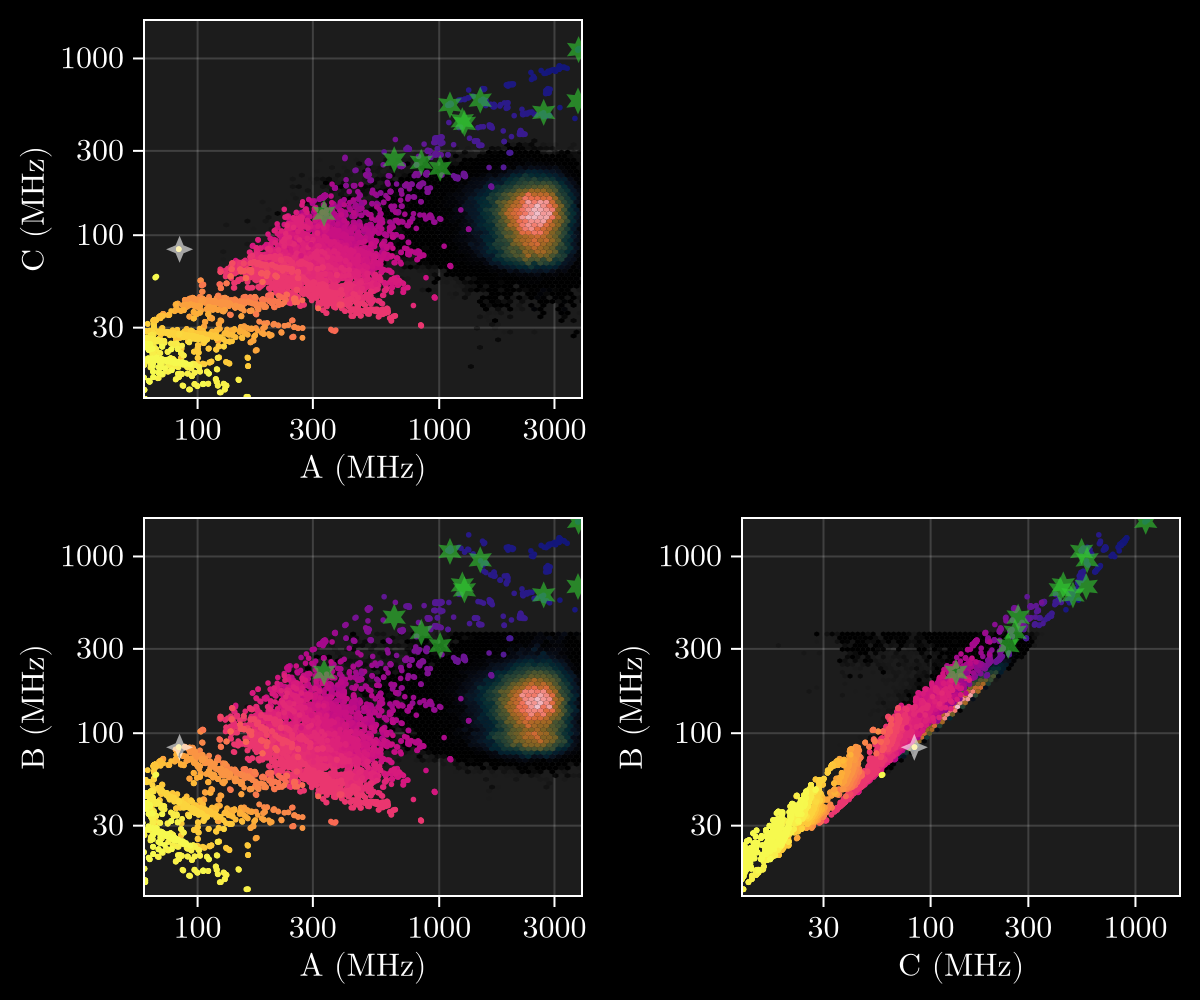

In [117]:
fig = Figure(size=(600, 500), fontsize=16,
    figure_padding=(10,10,10,10))
    
ax = Axis(fig[2, 1],
    xscale=log10,
    yscale=log10,
    xticks = [100, 300, 1000, 3000],
    yticks = [30, 100, 300, 1000],
    xlabel="A (MHz)",
    ylabel="B (MHz)",
    backgroundcolor = :grey11,
)

xlims!(ax,60,3900)
ylims!(ax,12,1650)

co = hexbin!(ax,A.*cm2MHz,B.*cm2MHz,
    cellsize = 0.025,
    threshold = 0.0,
    colormap = [Makie.to_color(:transparent); Makie.to_colormap(ColorSchemes.cmr_dusk)],
    # colorrange = (0,100),
)

co = scatter!(ax,ABCmat[1,.!msk].*cm2MHz,ABCmat[2,.!msk].*cm2MHz,color=Mmat[.!msk],
    colorrange=(78,766),
    colormap=ColorSchemes.linear_bmy_10_95_c71_n256, markersize=4)

for key in keys(radio_const)
    scatter!(ax,radio_const[key][1],radio_const[key][2],color=("limegreen",0.6), marker=:star6, markersize=15)
end
tindx = findall(map(x->x.uid, entries) .== 720) # C60+
scatter!(ax,ABCmat[1,tindx].*cm2MHz,ABCmat[2,tindx].*cm2MHz,color=("white",0.6), marker=:star4, markersize=15)

ax = Axis(fig[1, 1],
    xscale=log10,
    yscale=log10,
    xticks = [100, 300, 1000, 3000],
    yticks = [30, 100, 300, 1000],
    xlabel="A (MHz)",
    ylabel="C (MHz)",
    backgroundcolor = :grey11,
)

xlims!(ax,60,3900)
ylims!(ax,12,1650)

co = hexbin!(ax,A.*cm2MHz,C.*cm2MHz,
    cellsize = 0.025,
    threshold = 0.0,
    colormap = [Makie.to_color(:transparent); Makie.to_colormap(ColorSchemes.cmr_dusk)],
    # colorrange = (0,100),
)

co = scatter!(ax,ABCmat[1,.!msk].*cm2MHz,ABCmat[3,.!msk].*cm2MHz,color=Mmat[.!msk],
    colorrange=(78,766),
    colormap=ColorSchemes.linear_bmy_10_95_c71_n256, markersize=4)

for key in keys(radio_const)
    scatter!(ax,radio_const[key][1],radio_const[key][3],color=("limegreen",0.6), marker=:star6, markersize=15)
end
tindx = findall(map(x->x.uid, entries) .== 720) # C60+
scatter!(ax,ABCmat[1,tindx].*cm2MHz,ABCmat[3,tindx].*cm2MHz,color=("white",0.6), marker=:star4, markersize=15)

ax = Axis(fig[2, 2],
    xscale=log10,
    yscale=log10,
    xticks = [30, 100, 300, 1000],
    yticks = [30, 100, 300, 1000],
    xlabel="C (MHz)",
    ylabel="B (MHz)",
    backgroundcolor = :grey11,
)

xlims!(ax,12,1650)
ylims!(ax,12,1650)

co = hexbin!(ax,C.*cm2MHz,B.*cm2MHz,
    cellsize = 0.025,
    threshold = 0.0,
    colormap = [Makie.to_color(:transparent); Makie.to_colormap(ColorSchemes.cmr_dusk)],
    # colorrange = (0,100),
)

co = scatter!(ax,ABCmat[3,.!msk].*cm2MHz,ABCmat[2,.!msk].*cm2MHz,color=Mmat[.!msk],
    colorrange=(78,766),
    colormap=ColorSchemes.linear_bmy_10_95_c71_n256, markersize=4)

for key in keys(radio_const)
    scatter!(ax,radio_const[key][3],radio_const[key][2],color=("limegreen",0.6), marker=:star6, markersize=15)
end
tindx = findall(map(x->x.uid, entries) .== 720) # C60+
scatter!(ax,ABCmat[3,tindx].*cm2MHz,ABCmat[2,tindx].*cm2MHz,color=("white",0.6), marker=:star4, markersize=15)

resize_to_layout!(fig)
fig

# spAll Quick Check

In [10]:
using FITSIO, FreqTables

In [6]:
f = FITS("/uufs/chpc.utah.edu/common/home/sdss52/ipl-4/spectro/boss/redux/v6_2_1/summary/allepoch/spAll-lite-v6_2_1-allepoch.fits.gz")

File: /uufs/chpc.utah.edu/common/home/sdss52/ipl-4/spectro/boss/redux/v6_2_1/summary/allepoch/spAll-lite-v6_2_1-allepoch.fits.gz
Mode: "r" (read-only)
HDUs: Num  Name   Type   
      1           Image  
      2    SPALL  Table  

In [8]:
OBJTYPE = read(f[2],"OBJTYPE")

506550-element Vector{String}:
 "QSO"
 "QSO"
 "QSO"
 "QSO"
 "QSO"
 "QSO"
 "QSO"
 "QSO"
 "QSO"
 "QSO"
 "QSO"
 "QSO"
 "QSO"
 ⋮
 "science"
 "science"
 "QSO"
 "QSO"
 "science"
 "science"
 "science"
 "science"
 "QSO"
 "QSO"
 "science"
 "science"

In [9]:
close(f)

In [11]:
sort(freqtable(OBJTYPE))

3-element Named Vector{Int64}
Dim1             │ 
─────────────────┼───────
SPECTROPHOTO_STD │    337
QSO              │  25526
science          │ 480687

In [17]:
5_015_597/41_253

121.5813880202652

In [16]:
130_577_797/41_253

3165.2921484498097